<a href="https://colab.research.google.com/github/Daudi232/MSc_Data_Science/blob/main/advanced_nlp/covid_chat_bot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DESCRIPTION OF PROJECT

This project was a deliverable for the Advanced NLP course. The main idea was to build a chatbot that can provide research backed answers for user queries related to COVID-19. The dataset that the chatbot retrieves as context for providing it's responses is the CORD-19 dataset, it was filtered with respect to smoking and long-COVID keywords.

# DATA PRE-PROCESSING

### Installation of libraries to be used in this section

In [ ]:
!pip install transformers

## PART 1: Cleaning the metadata

At this stage we only need to work with a lightweight version of the metadata, so we will remove the papers with no abstracts and drop the columns that are not needed for now.

---
**Summary**:

* The original metadata had a total of 1056660 papers with 19 columns, using a total of 153.2+ MB in memory

* After cleaning, a total of 821116 papers were left with 3 columns, using only 25.1+ MB of memory

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Advanced NLP/Project Data/metadata.csv')

<ipython-input-2-da2d92f42779>:2: DtypeWarning: Columns (1,4,5,6,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Advanced NLP/Project Data/metadata.csv')


In [ ]:
df.head()

,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
3,2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,PMC,Role of endothelin-1 in lung disease,10.1186/rr44,PMC59574,11686871,no-cc,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001-02-22,"Fagan, Karen A; McMurtry, Ivan F; Rodman, David M",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/348055649b6b8cf2b9a37...,document_parses/pmc_json/PMC59574.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
4,9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,PMC,Gene expression in epithelial cells in respons...,10.1186/rr61,PMC59580,11686888,no-cc,Respiratory syncytial virus (RSV) and pneumoni...,2001-05-11,"Domachowske, Joseph B; Bonville, Cynthia A; Ro...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/5f48792a5fa08bed9f560...,document_parses/pmc_json/PMC59580.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056660 entries, 0 to 1056659
Data columns (total 19 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   cord_uid          1056660 non-null  object 
 1   sha               373766 non-null   object 
 2   source_x          1056660 non-null  object 
 3   title             1056157 non-null  object 
 4   doi               656780 non-null   object 
 5   pmcid             389571 non-null   object 
 6   pubmed_id         498932 non-null   object 
 7   license           1056660 non-null  object 
 8   abstract          821116 non-null   object 
 9   publish_time      1054846 non-null  object 
 10  authors           1032791 non-null  object 
 11  journal           969338 non-null   object 
 12  mag_id            0 non-null        float64
 13  who_covidence_id  482935 non-null   object 
 14  arxiv_id          14249 non-null    object 
 15  pdf_json_files    373766 non-null   object 
 16  

In [ ]:
df = df[['cord_uid', 'title','abstract']]

# how many papers do not have abstracts?
df['abstract'].isna().sum()

np.int64(235544)

In [ ]:
df = df.dropna(subset=['abstract'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 821116 entries, 0 to 1056659
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   cord_uid  821116 non-null  object
 1   title     821005 non-null  object
 2   abstract  821116 non-null  object
dtypes: object(3)
memory usage: 25.1+ MB


In [ ]:
# Save the smaller dataframe into csv format for next stage of pre-processing
# df.to_csv('/content/drive/MyDrive/Advanced NLP/Project Data/metadata_small.csv')

## PART 2A: Filtering the metadata with smoking and long-covid keywords

For this step, we will use regex matching.

**Summary**:
* There are 1454 papers with long-covid related keywords
* There are 8330 papers with smoking related keywords

In [ ]:
# ——— Long-COVID / Post-COVID terms ———
long_covid_keywords = [
    "long COVID",
    "long-haul COVID",
    "post-COVID syndrome",
    "post-COVID condition",
    "post-acute sequelae of COVID-19",
    "chronic COVID syndrome",
]

# ——— Smoking / Tobacco use ———
smoking_keywords = [
    "smoking",
    "tobacco",
    "cigarette",
    "nicotine",
    "secondhand smoke",
    "passive smoking",
    "cigar smoking",
    "pipe smoking",
    "vaping",
    "e-cigarette",
]


all_keywords = (
    long_covid_keywords +
    smoking_keywords
    )

In [ ]:
import re

regex_pattern = r'\b(?:{})\b'.format('|'.join(all_keywords))
flags = re.IGNORECASE

# Filter abstracts containing smoking and long-covid related terms
mask = df['abstract'].str.contains(regex_pattern, flags=flags, na=False)

In [ ]:
filtered_df = df[mask].copy()
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9760 entries, 8 to 1056654
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   cord_uid  9760 non-null   object
 1   title     9759 non-null   object
 2   abstract  9760 non-null   object
dtypes: object(3)
memory usage: 305.0+ KB


In [ ]:
# prompt: generate 2 different dataframes from the filtered dataframe with respect to each keyword

# Create individual DataFrames for each keyword group
dataframes = {}
for group_name, keywords in keyword_groups.items():
    regex_pattern = r'\b(?:{})\b'.format('|'.join(keywords))
    flags = re.IGNORECASE
    mask = filtered_df['abstract'].str.contains(regex_pattern, flags=flags, na=False)
    dataframes[group_name] = filtered_df[mask].copy()

In [ ]:
df_1 = dataframes['long_covid'].reset_index(drop=True)
df_2 = dataframes['smoking'].reset_index(drop=True)

In [ ]:
print (df_1.info())
print()
print (df_2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1454 entries, 0 to 1453
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   cord_uid  1454 non-null   object
 1   title     1454 non-null   object
 2   abstract  1454 non-null   object
dtypes: object(3)
memory usage: 34.2+ KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8330 entries, 0 to 8329
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   cord_uid  8330 non-null   object
 1   title     8329 non-null   object
 2   abstract  8330 non-null   object
dtypes: object(3)
memory usage: 195.4+ KB
None


## PART 2B: Validation of filtering

In this part, we verify whether the filtered dataset was truly related to the smoking and long-covid keywords. We use a zero-shot classification model from hugging-face.

We chose to pick 5 random samples from each dataframe in order to reduce the computational requirements.

---
**Summary:**
* The long-covid papers had the highest scores validating that they are truly related to long-covid. Considering they are are few in number, this was important.

* The smoking papers had an fair score, but considering they are high in number, this was not bad.




In [ ]:
from transformers import pipeline

# Initialize zero-shot classification pipeline
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


### Long Covid Scores

In [ ]:
import random

# Step 1: Randomly sample 5 abstracts
sampled_indices = random.sample(range(len(df_1)), 5)
sampled_df = df_1.iloc[sampled_indices].copy()

# Step 2: Define candidate labels
candidate_labels = ["about smoking", "about long-COVID", "not related"]

# Step 3: Run classification and store results
results = []

for _, row in sampled_df.iterrows():
    abstract = row["abstract"]
    classification = classifier(abstract, candidate_labels=candidate_labels)

    # Top label and its score
    top_label = classification["labels"][0]
    top_score = classification["scores"][0]

    results.append({
        "cord_uid": row["cord_uid"],
        "title": row["title"],
        "abstract": abstract,
        "predicted_label": top_label,
        "score": round(top_score, 4),
        "all_labels": classification["labels"],
        "all_scores": [round(s, 4) for s in classification["scores"]],
    })

# Step 4: Save/Display results
result_df = pd.DataFrame(results)
print(result_df[["cord_uid", "title", "predicted_label", "score"]])

   cord_uid                                              title  \
0  171k9wpz  Prevention and Treatment of Life-Threatening C...   
1  i1a1fo9c  Long COVID a New Derivative in the Chaos of SA...   
2  njsd3zt1  Neuroinflammation in Severe Acute Respiratory ...   
3  nqi8diez  18F-FDG-PET/CT in SARS-CoV-2 infection and its...   
4  zmo6uzc6                  Pragmatic impairment and COVID-19   

    predicted_label   score  
0  about long-COVID  0.9744  
1  about long-COVID  0.9775  
2  about long-COVID  0.8036  
3  about long-COVID  0.9402  
4  about long-COVID  0.9921  


### Sample abstract text from long covid dataframe

In [ ]:
df_1['abstract'][df_1['cord_uid'] == 'njsd3zt1']

,abstract
1258,Peripheral inflammation and neuroinflammation ...


In [ ]:
df_1['abstract'][1258]

'Peripheral inflammation and neuroinflammation are host-mounted to eliminate injury, infection, or toxin to restore homeostasis. However, when inflammation persists, it may promote collateral tissue damage that ultimately culminates in pathological peripheral damage or neurodegeneration. Since the beginning of the Severe Acute Respiratory Syndrome Coronavirus-2 (SARS-CoV-2) pandemic, responsible of Coronavirus disease 2019 (COVID-19), accumulating evidence describes neurological manifestations and complications worldwide particularly in approximately one-third of patients with COVID-19 particularly in those affected with the severe forms of the disease. Different access routes to the central nervous system have been identified. One immediately used is the entrance by the olfactory and trigeminus nervous affecting olfactory and sensory nerve endings when individuals get the infection by the intranasal route. It can also reach the central nervous system through the choroid plexuses and p

### Smoking scores

In [ ]:
import random

# Step 1: Randomly sample 5 abstracts
sampled_indices = random.sample(range(len(df_2)), 5)
sampled_df = df_2.iloc[sampled_indices].copy()

# Step 2: Define candidate labels
candidate_labels = ["about smoking", "about long-COVID", "not related"]

# Step 3: Run classification and store results
results = []

for _, row in sampled_df.iterrows():
    abstract = row["abstract"]
    classification = classifier(abstract, candidate_labels=candidate_labels)

    # Top label and its score
    top_label = classification["labels"][0]
    top_score = classification["scores"][0]

    results.append({
        "cord_uid": row["cord_uid"],
        "title": row["title"],
        "abstract": abstract,
        "predicted_label": top_label,
        "score": round(top_score, 4),
        "all_labels": classification["labels"],
        "all_scores": [round(s, 4) for s in classification["scores"]],
    })

# Step 4: Save/Display results
result_df = pd.DataFrame(results)
print(result_df[["cord_uid", "title", "predicted_label", "score"]])

   cord_uid                                              title  \
0  vrcp8yvp  Serious Psychological Distress Is Associated w...   
1  fe14iohb  Association Between Smoking and SARS-CoV-2 Inf...   
2  sxhrviuk  Serum gamma-glutamyl transferase, a marker of ...   
3  xcijze16  Coronavirus Disease 2019 (COVID-19) Disease Se...   
4  xkbdyirs  Our Experience with Using WatchPat® (Itamar Me...   

    predicted_label   score  
0     about smoking  0.8681  
1     about smoking  0.9069  
2     about smoking  0.5421  
3  about long-COVID  0.4196  
4     about smoking  0.4342  


### Sample abstract texts from smoking dataframe

In [ ]:
df_2['abstract'][df_2['cord_uid'] == 'xcijze16']

,abstract
7785,BACKGROUND: Pregnancy has been reported to be ...


In [ ]:
# This paper seems to be talking about pregnancy. It has a lower score

df_2['abstract'][7785]

'BACKGROUND: Pregnancy has been reported to be a risk factor for severe COVID-19. We evaluated the impact of pregnancy on severe COVID-19 and mortality in an electronic medical record (EMR) database that enabled exclusion of labor and delivery (L&D) encounters. METHODS: In this retrospective cohort study, EMRs from 82 healthcare facilities in the Cerner COVID-19 Datamart were analyzed. The study comprised 38 106 individuals aged 18-45 years old with COVID-19 who had emergency department, urgent care, or inpatient encounters from December 2019 to September 2020. Subgroups were balanced through propensity score weights for age, race, smoking status, and number of comorbidities. The primary outcome was COVID-19-related mortality; secondary outcomes were markers of severe COVID-19: intubations, mechanical ventilation, use of vasopressors, diagnosis of sepsis, and diagnosis of acute respiratory distress syndrome. RESULTS: In comparing pregnant and nonpregnant women, no statistical differenc

In [ ]:
df_2['abstract'][df_2['cord_uid'] == 'fe14iohb']

,abstract
7561,BACKGROUND: Several studies have reported a lo...


In [ ]:
# This paper speaks more about smoking. It has a higher score

df_2['abstract'][7561]

'BACKGROUND: Several studies have reported a low prevalence of current smoking among hospitalized COVID-19 cases; however, no definitive conclusions can be drawn. OBJECTIVE: We investigated the association of tobacco smoke exposure with nasopharyngeal swab (NPS) test results for SARS-CoV-2 infection and disease severity accounting for possible confounders. METHODS: The nationwide, self-administered, cross-sectional web-based Italian National Epidemiological Survey on COVID-19 (EPICOVID19) was administered to an Italian population of 198,822 adult volunteers who filled in an online questionnaire between April 13 and June 2, 2020. For this study, we analyzed 6857 individuals with known NPS test results. The associations of smoking status and the dose-response relationship with a positive NPS test result and infection severity were calculated as odds ratios (ORs) with 95% CIs by means of logistic and multinomial regression models adjusting for sociodemographic, clinical, and behavioral ch

In [ ]:
# filtered_df.to_csv('/content/drive/MyDrive/Advanced NLP/Project Data/metadata_smoking_long_covid.csv', index=False)

## PART 3A: Extracting the identifiers (cord_uid) from the metadata

In this part, we will use the identifiers (cord_uid) from the filtered dataframe in the previous part to filter the original metadata dataframe.

In [ ]:
import pandas as pd

# We load the metadata dataframe
df = pd.read_csv('/content/drive/MyDrive/Advanced NLP/Project Data/metadata.csv')

<ipython-input-53-b4d2708cee84>:1: DtypeWarning: Columns (1,4,5,6,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Advanced NLP/Project Data/metadata.csv')


In [ ]:
df.head()

,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
3,2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,PMC,Role of endothelin-1 in lung disease,10.1186/rr44,PMC59574,11686871,no-cc,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001-02-22,"Fagan, Karen A; McMurtry, Ivan F; Rodman, David M",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/348055649b6b8cf2b9a37...,document_parses/pmc_json/PMC59574.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
4,9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,PMC,Gene expression in epithelial cells in respons...,10.1186/rr61,PMC59580,11686888,no-cc,Respiratory syncytial virus (RSV) and pneumoni...,2001-05-11,"Domachowske, Joseph B; Bonville, Cynthia A; Ro...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/5f48792a5fa08bed9f560...,document_parses/pmc_json/PMC59580.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN


In [ ]:
# How many identifiers do we have?
ids = filtered_df['cord_uid'].unique()
print(ids.shape)

(9142,)


In [ ]:
# In the original metadata, the number is higher.. why?
df[df['cord_uid'].isin(ids)].shape

(9917, 19)

In [ ]:
# Looks like we have duplicates
df['cord_uid'][df['cord_uid'].isin(ids)].duplicated().sum()

np.int64(775)

In [ ]:
# We reduce the metadata to only include the smoking + long-covid papers
filtered_metadata = df[df['cord_uid'].isin(ids)].copy()
filtered_metadata.reset_index(drop = True, inplace = True)

In [ ]:
filtered_metadata.head()

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,8qnrcgnk,faaf1022ccfe93b032c5608097a53543ba24aedb,PMC,Heme oxygenase-1 and carbon monoxide in pulmon...,10.1186/1465-9921-4-7,PMC193681,12964953,no-cc,"Heme oxygenase-1 (HO-1), an inducible stress p...",2003-08-07,"Slebos, Dirk-Jan; Ryter, Stefan W; Choi, Augus...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/faaf1022ccfe93b032c56...,document_parses/pmc_json/PMC193681.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,NaN
1,bnnl700a,a78fd1b34372e1e54bf2a192d04aa36670cea307,PMC,Public awareness of risk factors for cancer am...,10.1186/1471-2458-6-2,PMC1351169,16403223,cc-by,BACKGROUND: The present study aimed to provide...,2006-01-10,"Inoue, Manami; Iwasaki, Motoki; Otani, Tetsuya...",BMC Public Health,NaN,NaN,NaN,document_parses/pdf_json/a78fd1b34372e1e54bf2a...,document_parses/pmc_json/PMC1351169.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,NaN
2,ft5wl70x,b97de55ba907c3b1f3048bfecf6b2b3970363541,PMC,Involvement of microRNAs in physiological and ...,10.1186/1465-9921-11-159,PMC3001429,21092244,cc-by,"To date, at least 900 different microRNA (miRN...",2010-11-23,"Tomankova, Tereza; Petrek, Martin; Kriegova, Eva",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/b97de55ba907c3b1f3048...,document_parses/pmc_json/PMC3001429.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
3,1h6jz1h5,79979652a864cef3a41342ccb1add48e5ad0cf85,PMC,Plant Plastid Engineering,10.2174/138920210793175912,PMC3048312,21532834,cc-by,Genetic material in plants is distributed into...,2010-11-03,"Wani, Shabir H.; Haider, Nadia; Kumar, Hitesh;...",Curr Genomics,NaN,NaN,NaN,document_parses/pdf_json/79979652a864cef3a4134...,document_parses/pmc_json/PMC3048312.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
4,5is9kc52,a4ffcadecc4b60c30df8f699c480724523272e62,PMC,First Discovery and Stucture-Activity Relation...,10.1371/journal.pone.0052933,PMC3532156,23285230,cc-by,A series of phenanthroquinolizidine alkaloids ...,2012-12-28,"Wang, Ziwen; Feng, Anzheng; Cui, Mingbo; Liu, ...",PLoS One,NaN,NaN,NaN,document_parses/pdf_json/a4ffcadecc4b60c30df8f...,document_parses/pmc_json/PMC3532156.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN


In [ ]:
filtered_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9917 entries, 0 to 9916
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cord_uid          9917 non-null   object 
 1   sha               4191 non-null   object 
 2   source_x          9917 non-null   object 
 3   title             9916 non-null   object 
 4   doi               6861 non-null   object 
 5   pmcid             4154 non-null   object 
 6   pubmed_id         5424 non-null   object 
 7   license           9917 non-null   object 
 8   abstract          9796 non-null   object 
 9   publish_time      9904 non-null   object 
 10  authors           9823 non-null   object 
 11  journal           8946 non-null   object 
 12  mag_id            0 non-null      float64
 13  who_covidence_id  3957 non-null   object 
 14  arxiv_id          21 non-null     object 
 15  pdf_json_files    4191 non-null   object 
 16  pmc_json_files    3592 non-null   object 


In [ ]:
# Filter out irrelevant columns
filtered_metadata.drop(columns = ['mag_id', 'arxiv_id', 'sha', 'who_covidence_id'], inplace = True)

# Deal with the duplicates wrt cord_uid
filtered_metadata.drop_duplicates(subset = ['cord_uid'], inplace = True)

# reset indices
filtered_metadata.reset_index(drop = True, inplace = True)

In [ ]:
filtered_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9142 entries, 0 to 9141
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cord_uid        9142 non-null   object 
 1   source_x        9142 non-null   object 
 2   title           9141 non-null   object 
 3   doi             6810 non-null   object 
 4   pmcid           4141 non-null   object 
 5   pubmed_id       5391 non-null   object 
 6   license         9142 non-null   object 
 7   abstract        9121 non-null   object 
 8   publish_time    9129 non-null   object 
 9   authors         9103 non-null   object 
 10  journal         8203 non-null   object 
 11  pdf_json_files  4179 non-null   object 
 12  pmc_json_files  3581 non-null   object 
 13  url             6955 non-null   object 
 14  s2_id           8568 non-null   float64
dtypes: float64(1), object(14)
memory usage: 1.0+ MB


In [ ]:
# filtered_metadata.to_csv('filtered_metadata_p1.csv', index = False)

## PART 3B: Extracting the Full texts from the Original CORD-19 Dataset

This part was done in a local jupyter notebook because the original CORD-19 Dataset was downloaded locally. Storage constraints in the cloud was the reason

---

__Summary__


* 4963 papers did not have pdf_json_files path attached to them in our metadata.

* I decided to use the abstract as the full text for such papers.. this will provide limited information, but atleast it will be something instead of having to lose 5000+ papers..

* 21 papers did not have abstracts so they were dropped

* 4179 papers had full texts.. we extracted the full text

* This sums to a total of 9121 papers with full texts (or abstracts as replacements)

In [ ]:
# Local path for the full text json
PDF_JSON_DIR = '/media/work/MSc Data Science/SEMESTER 2/Advanced Natural Language Processing/Labs/2022-06-02/document_parses/pdf_json'

In [ ]:
import os
import json
import pandas as pd
from tqdm import tqdm

In [ ]:
# We load the dataframe from part 3A
df = pd.read_csv('filtered_metadata_p1.csv')
metadata_df = df.copy()

### Extraction code

In [ ]:
# Prepare list to store full text entries
full_texts = []

# Iterate over each row with available PDF JSON path
for idx, row in tqdm(metadata_df.iterrows(), total=len(metadata_df)):
    pdf_paths = row.get('pdf_json_files')
    cord_uid = row['cord_uid']

    if pd.isna(pdf_paths):
        # No PDF file available — will fall back later to abstract
        continue

    # Handle multiple paths (semicolon-separated)
    for rel_path in pdf_paths.split('; '):
        json_path = os.path.join(PDF_JSON_DIR, os.path.basename(rel_path))

        try:
            with open(json_path, 'r', encoding='utf-8') as f:
                paper = json.load(f)

            # Extract full text (just concatenating all body paragraphs)
            full_text = ' '.join([p['text'] for p in paper.get('body_text', [])])

            if full_text.strip():
                full_texts.append({
                    'cord_uid': cord_uid,
                    'text': full_text,
                    'text_source': 'full_text'
                })
            break  # Use first successfully loaded file

        except Exception as e:
            print(f"Error reading {json_path}: {e}")


100%|█████████████████████████████████████████████████████████| 9142/9142 [00:04<00:00, 2067.43it/s]


In [ ]:
# A total of 4179 papers had full texts

len(full_texts)

4179

In [ ]:
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9142 entries, 0 to 9141
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cord_uid        9142 non-null   object 
 1   source_x        9142 non-null   object 
 2   title           9141 non-null   object 
 3   doi             6810 non-null   object 
 4   pmcid           4141 non-null   object 
 5   pubmed_id       5391 non-null   float64
 6   license         9142 non-null   object 
 7   abstract        9121 non-null   object 
 8   publish_time    9129 non-null   object 
 9   authors         9103 non-null   object 
 10  journal         8203 non-null   object 
 11  pdf_json_files  4179 non-null   object 
 12  pmc_json_files  3581 non-null   object 
 13  url             6955 non-null   object 
 14  s2_id           8568 non-null   float64
dtypes: float64(2), object(13)
memory usage: 1.0+ MB


In [ ]:
# Drop papers which do not have abstracts. We should have done this earlier. My bad

metadata_df.dropna(subset = ['abstract'], inplace = True)

In [ ]:
# Handle missing full texts (with missing pdf json files), by using the abstracts instead

abstract_rows = metadata_df[pd.isna(metadata_df['pdf_json_files'])][['cord_uid', 'abstract']]

# Merge the abstracts at the end of the full texts list..
for _, row in abstract_rows.iterrows():
    full_texts.append({
        'cord_uid': row['cord_uid'],
        'text': row['abstract'],
        'text_source': 'abstract'
    })

In [ ]:
# The number ties with the number of papers with abstracts, so the process was successful..
len(full_texts)

9121

In [ ]:
full_text_df = pd.DataFrame(full_texts)

In [ ]:
full_text_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9121 entries, 0 to 9120
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   cord_uid     9121 non-null   object
 1   text         9121 non-null   object
 2   text_source  9121 non-null   object
dtypes: object(3)
memory usage: 213.9+ KB


In [ ]:
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9121 entries, 0 to 9141
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cord_uid        9121 non-null   object 
 1   source_x        9121 non-null   object 
 2   title           9120 non-null   object 
 3   doi             6809 non-null   object 
 4   pmcid           4141 non-null   object 
 5   pubmed_id       5391 non-null   float64
 6   license         9121 non-null   object 
 7   abstract        9121 non-null   object 
 8   publish_time    9108 non-null   object 
 9   authors         9082 non-null   object 
 10  journal         8182 non-null   object 
 11  pdf_json_files  4179 non-null   object 
 12  pmc_json_files  3581 non-null   object 
 13  url             6954 non-null   object 
 14  s2_id           8547 non-null   float64
dtypes: float64(2), object(13)
memory usage: 1.1+ MB


In [ ]:
# I want the other columns in the metadata included, so I will merge with the metadata_df

complete_df = full_text_df.merge(metadata_df, on = 'cord_uid')

In [ ]:
complete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9121 entries, 0 to 9120
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cord_uid        9121 non-null   object 
 1   text            9121 non-null   object 
 2   text_source     9121 non-null   object 
 3   source_x        9121 non-null   object 
 4   title           9120 non-null   object 
 5   doi             6809 non-null   object 
 6   pmcid           4141 non-null   object 
 7   pubmed_id       5391 non-null   float64
 8   license         9121 non-null   object 
 9   abstract        9121 non-null   object 
 10  publish_time    9108 non-null   object 
 11  authors         9082 non-null   object 
 12  journal         8182 non-null   object 
 13  pdf_json_files  4179 non-null   object 
 14  pmc_json_files  3581 non-null   object 
 15  url             6954 non-null   object 
 16  s2_id           8547 non-null   float64
dtypes: float64(2), object(15)
memory 

In [ ]:
complete_df[['text','abstract', 'text_source']]

,text,abstract,text_source
0,The heme oxygenase-1/carbon monoxide (HO-1/CO)...,"Heme oxygenase-1 (HO-1), an inducible stress p...",full_text
1,"In Japan, cancer has been recognized as a majo...",BACKGROUND: The present study aimed to provide...,full_text
2,"A. miRNA definition, biology and function Disc...","To date, at least 900 different microRNA (miRN...",full_text
3,Genetic material in plants is distributed into...,Genetic material in plants is distributed into...,full_text
4,Plant viruses cause numerous diseases in a wid...,A series of phenanthroquinolizidine alkaloids ...,full_text
...,...,...,...
9116,The paper entitled “The impact of COPD and smo...,The paper entitled “The impact of COPD and smo...,abstract
9117,TOPIC: Obstructive Lung Diseases TYPE: Origina...,TOPIC: Obstructive Lung Diseases TYPE: Origina...,abstract
9118,OBJECTIVES: The impact of the COVID-19 pandemi...,OBJECTIVES: The impact of the COVID-19 pandemi...,abstract
9119,BACKGROUND: Pictorial health warning label (PH...,BACKGROUND: Pictorial health warning label (PH...,abstract


In [ ]:
# complete_df.to_csv('smoking_long_covid_full_txt.csv', index = False)

## PART 3C: Validating the full text extraction

### Installation of libraries required for this section

In [ ]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Advanced NLP/Project Data/smoking_long_covid_full_txt.csv")

In [ ]:
df.head()

,cord_uid,text,text_source,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,pdf_json_files,pmc_json_files,url,s2_id
0,8qnrcgnk,The heme oxygenase-1/carbon monoxide (HO-1/CO)...,full_text,PMC,Heme oxygenase-1 and carbon monoxide in pulmon...,10.1186/1465-9921-4-7,PMC193681,12964953.0,no-cc,"Heme oxygenase-1 (HO-1), an inducible stress p...",2003-08-07,"Slebos, Dirk-Jan; Ryter, Stefan W; Choi, Augus...",Respir Res,document_parses/pdf_json/faaf1022ccfe93b032c56...,document_parses/pmc_json/PMC193681.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,NaN
1,bnnl700a,"In Japan, cancer has been recognized as a majo...",full_text,PMC,Public awareness of risk factors for cancer am...,10.1186/1471-2458-6-2,PMC1351169,16403223.0,cc-by,BACKGROUND: The present study aimed to provide...,2006-01-10,"Inoue, Manami; Iwasaki, Motoki; Otani, Tetsuya...",BMC Public Health,document_parses/pdf_json/a78fd1b34372e1e54bf2a...,document_parses/pmc_json/PMC1351169.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,NaN
2,ft5wl70x,"A. miRNA definition, biology and function Disc...",full_text,PMC,Involvement of microRNAs in physiological and ...,10.1186/1465-9921-11-159,PMC3001429,21092244.0,cc-by,"To date, at least 900 different microRNA (miRN...",2010-11-23,"Tomankova, Tereza; Petrek, Martin; Kriegova, Eva",Respir Res,document_parses/pdf_json/b97de55ba907c3b1f3048...,document_parses/pmc_json/PMC3001429.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
3,1h6jz1h5,Genetic material in plants is distributed into...,full_text,PMC,Plant Plastid Engineering,10.2174/138920210793175912,PMC3048312,21532834.0,cc-by,Genetic material in plants is distributed into...,2010-11-03,"Wani, Shabir H.; Haider, Nadia; Kumar, Hitesh;...",Curr Genomics,document_parses/pdf_json/79979652a864cef3a4134...,document_parses/pmc_json/PMC3048312.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
4,5is9kc52,Plant viruses cause numerous diseases in a wid...,full_text,PMC,First Discovery and Stucture-Activity Relation...,10.1371/journal.pone.0052933,PMC3532156,23285230.0,cc-by,A series of phenanthroquinolizidine alkaloids ...,2012-12-28,"Wang, Ziwen; Feng, Anzheng; Cui, Mingbo; Liu, ...",PLoS One,document_parses/pdf_json/a4ffcadecc4b60c30df8f...,document_parses/pmc_json/PMC3532156.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9121 entries, 0 to 9120
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cord_uid        9121 non-null   object 
 1   text            9121 non-null   object 
 2   text_source     9121 non-null   object 
 3   source_x        9121 non-null   object 
 4   title           9120 non-null   object 
 5   doi             6809 non-null   object 
 6   pmcid           4141 non-null   object 
 7   pubmed_id       5391 non-null   float64
 8   license         9121 non-null   object 
 9   abstract        9121 non-null   object 
 10  publish_time    9108 non-null   object 
 11  authors         9082 non-null   object 
 12  journal         8182 non-null   object 
 13  pdf_json_files  4179 non-null   object 
 14  pmc_json_files  3581 non-null   object 
 15  url             6954 non-null   object 
 16  s2_id           8547 non-null   float64
dtypes: float64(2), object(15)
memory 

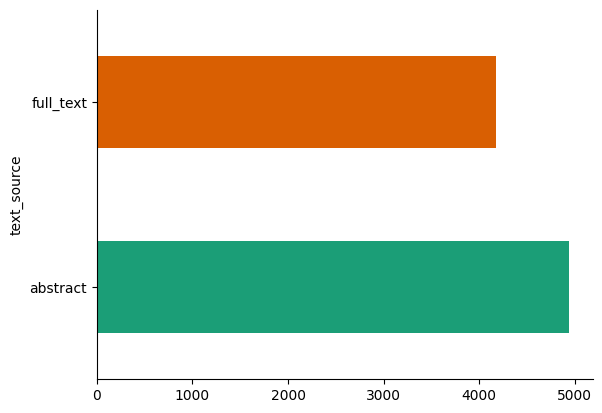

In [ ]:
# @title Full text Vs Abstracts distribution

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('text_source').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# prompt: generate code that samples random numbers from the row indeces having full text in the text_source column

import numpy as np

# Get the indices of rows where 'text_source' is 'full text'
full_text_indices = df[df['text_source'] == 'full_text'].index.tolist()

# Sample 5 random indices from the full_text_indices list
random_full_text_indices = np.random.choice(full_text_indices, size=10, replace=False)

In [ ]:
random_full_text_indices

array([3520, 3485, 1932, 3170, 3207, 2333,   64, 3029,  502, 2900])

In [ ]:
# A view of the sampled papers
# A confirmation that they are not the same, otherwise similarity score will be useless

for i in random_full_text_indices:
  print (df.loc[i, ['text', 'abstract']])

text        Cigarette smoking (CS) is a significant public...
abstract    BACKGROUND: Influenza is a highly contagious, ...
Name: 1546, dtype: object
text        Intervention and comparator: Arm I: Decaffeina...
abstract    OBJECTIVES: The primary objectives of the stud...
Name: 100, dtype: object
text        It has been estimated that approximately 5-10%...
abstract    BACKGROUND: It remains unknown whether and to ...
Name: 840, dtype: object
text        The genome size of RNA viruses is highly varia...
abstract    Nonretroviral integrated RNA viruses (NIRVs) a...
Name: 720, dtype: object
text        exposure to smoke from biomass fuel, occupatio...
abstract    Cigarette smoking is reported in about one thi...
Name: 730, dtype: object


In [ ]:
# Randomly selected texts to be used for validation

full_text = df['text'][random_full_text_indices]
abstract = df['abstract'][random_full_text_indices]

In [ ]:
full_text.reset_index(drop=True, inplace=True)
abstract.reset_index(drop=True, inplace=True)

In [ ]:
from sentence_transformers import SentenceTransformer, util

# We use the all-mpnet-base-v2 model to compute embeddings for our sample texts
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Encode texts to embeddings
embeddings_full_text = model.encode(full_text)
embeddings_abstract = model.encode(abstract)

### Similarity Scores between abstracts and Full texts

In [ ]:
# Compute cosine similarity between the two embeddings

for i in range(10):
  similarity_score = util.cos_sim(embeddings_full_text[i], embeddings_abstract[i])
  print(f"Similarity score: {similarity_score.item():.4f}")

Similarity score: 0.7956
Similarity score: 0.6246
Similarity score: 0.9391
Similarity score: 0.7153
Similarity score: 0.6946
Similarity score: 0.8433
Similarity score: 0.8315
Similarity score: 0.8479
Similarity score: 0.8236
Similarity score: 0.8855


## PART 3D: Further exploration and cleaning of the dataset

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Advanced NLP/Project Data/smoking_long_covid_full_txt.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9121 entries, 0 to 9120
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cord_uid        9121 non-null   object 
 1   text            9121 non-null   object 
 2   text_source     9121 non-null   object 
 3   source_x        9121 non-null   object 
 4   title           9120 non-null   object 
 5   doi             6809 non-null   object 
 6   pmcid           4141 non-null   object 
 7   pubmed_id       5391 non-null   float64
 8   license         9121 non-null   object 
 9   abstract        9121 non-null   object 
 10  publish_time    9108 non-null   object 
 11  authors         9082 non-null   object 
 12  journal         8182 non-null   object 
 13  pdf_json_files  4179 non-null   object 
 14  pmc_json_files  3581 non-null   object 
 15  url             6954 non-null   object 
 16  s2_id           8547 non-null   float64
dtypes: float64(2), object(15)
memory 

In [ ]:
# prompt: i want two new columns with word counts of the text column

df['text_word_count'] = df['text'].apply(lambda x: len(x.split()))
df.head()

,cord_uid,text,text_source,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,pdf_json_files,pmc_json_files,url,s2_id,text_word_count
0,8qnrcgnk,The heme oxygenase-1/carbon monoxide (HO-1/CO)...,full_text,PMC,Heme oxygenase-1 and carbon monoxide in pulmon...,10.1186/1465-9921-4-7,PMC193681,12964953.0,no-cc,"Heme oxygenase-1 (HO-1), an inducible stress p...",2003-08-07,"Slebos, Dirk-Jan; Ryter, Stefan W; Choi, Augus...",Respir Res,document_parses/pdf_json/faaf1022ccfe93b032c56...,document_parses/pmc_json/PMC193681.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,NaN,5541
1,bnnl700a,"In Japan, cancer has been recognized as a majo...",full_text,PMC,Public awareness of risk factors for cancer am...,10.1186/1471-2458-6-2,PMC1351169,16403223.0,cc-by,BACKGROUND: The present study aimed to provide...,2006-01-10,"Inoue, Manami; Iwasaki, Motoki; Otani, Tetsuya...",BMC Public Health,document_parses/pdf_json/a78fd1b34372e1e54bf2a...,document_parses/pmc_json/PMC1351169.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,NaN,1852
2,ft5wl70x,"A. miRNA definition, biology and function Disc...",full_text,PMC,Involvement of microRNAs in physiological and ...,10.1186/1465-9921-11-159,PMC3001429,21092244.0,cc-by,"To date, at least 900 different microRNA (miRN...",2010-11-23,"Tomankova, Tereza; Petrek, Martin; Kriegova, Eva",Respir Res,document_parses/pdf_json/b97de55ba907c3b1f3048...,document_parses/pmc_json/PMC3001429.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN,3119
3,1h6jz1h5,Genetic material in plants is distributed into...,full_text,PMC,Plant Plastid Engineering,10.2174/138920210793175912,PMC3048312,21532834.0,cc-by,Genetic material in plants is distributed into...,2010-11-03,"Wani, Shabir H.; Haider, Nadia; Kumar, Hitesh;...",Curr Genomics,document_parses/pdf_json/79979652a864cef3a4134...,document_parses/pmc_json/PMC3048312.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN,5495
4,5is9kc52,Plant viruses cause numerous diseases in a wid...,full_text,PMC,First Discovery and Stucture-Activity Relation...,10.1371/journal.pone.0052933,PMC3532156,23285230.0,cc-by,A series of phenanthroquinolizidine alkaloids ...,2012-12-28,"Wang, Ziwen; Feng, Anzheng; Cui, Mingbo; Liu, ...",PLoS One,document_parses/pdf_json/a4ffcadecc4b60c30df8f...,document_parses/pmc_json/PMC3532156.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN,4562


In [ ]:
# 54 percent of the text source is abstract
# 46 percent is full text

df['text_source'].value_counts()/len(df)

,count
text_source,
abstract,0.541827
full_text,0.458173


### Text word count Distribution

In [ ]:
df['text_word_count'].describe()

,text_word_count
count,9121.000000
mean,1882.285714
std,2929.067058
min,1.000000
25%,247.000000
50%,401.000000
75%,3219.000000
max,171948.000000


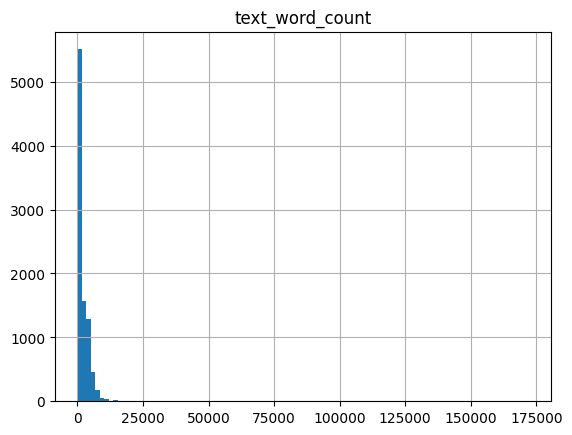

In [ ]:
df.hist(column='text_word_count', bins = 100);

<Axes: >

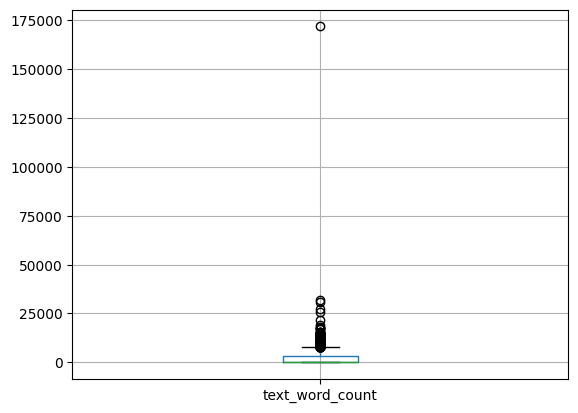

In [ ]:
df.boxplot(column='text_word_count')

### A close-up exploration into some paper's texts

In [ ]:
# This is absurd!
df['text'][df['text_word_count'] == 1]

,text
1601,Supplementary


In [ ]:
df[df['text_word_count'] == 1]

,cord_uid,text,text_source,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,pdf_json_files,pmc_json_files,url,s2_id,text_word_count
1601,csaqtb5z,Supplementary,full_text,Medline; PMC,Degradation of SARS-CoV-2 receptor ACE2 by the...,10.1007/s11684-021-0837-6,PMC7843238,33511555.0,no-cc,An unexpected observation among the COVID-19 p...,2021-01-29,"Wang, Guizhen; Zhao, Qun; Zhang, Hui; Liang, F...",Front Med,document_parses/pdf_json/b56f5ecfa2ae4e120f09c...,NaN,https://doi.org/10.1007/s11684-021-0837-6; htt...,231724364.0,1


In [ ]:
# The abstract is longer than full text. More informative!!
df['abstract'][1601]

'An unexpected observation among the COVID-19 pandemic is that smokers constituted only 1.4%–18.5% of hospitalized adults, calling for an urgent investigation to determine the role of smoking in SARS-CoV-2 infection. Here, we show that cigarette smoke extract (CSE) and carcinogen benzo(a)pyrene (BaP) increase ACE2 mRNA but trigger ACE2 protein catabolism. BaP induces an aryl hydrocarbon receptor (AhR)-dependent upregulation of the ubiquitin E3 ligase Skp2 for ACE2 ubiquitination. ACE2 in lung tissues of non-smokers is higher than in smokers, consistent with the findings that tobacco carcinogens downregulate ACE2 in mice. Tobacco carcinogens inhibit SARS-CoV-2 spike protein pseudovirions infection of the cells. Given that tobacco smoke accounts for 8 million deaths including 2.1 million cancer deaths annually and Skp2 is an oncoprotein, tobacco use should not be recommended and cessation plan should be prepared for smokers in COVID-19 pandemic. ELECTRONIC SUPPLEMENTARY MATERIAL: Supplem

In [ ]:
df['text'][df['text_word_count'] <= 20]

,text
1601,Supplementary
4192,Robust enforcement of tobacco control legislat...
6970,KEY MESSAGE: Production of ORF8 protein from S...
7037,Background and
8473,Smoking and COPD are risk factors for severe C...
8536,After recovering from acute COVID-19 infection...
8858,"With grit, urgency and creativity, scientists ..."


In [ ]:
df['abstract'][4192]

'Robust enforcement of tobacco control legislation is helping curb tobacco use in the Russian Federation. Andrey Shukshin reports.'

In [ ]:
df['abstract'][6970]


'KEY MESSAGE: Production of ORF8 protein from SARS-CoV-2 in tobacco BY-2 cells.'

In [ ]:
df['abstract'][7037]

'Background and'

In [ ]:
df['abstract'][8473]

'Smoking and COPD are risk factors for severe COVID-19 https://bit.ly/2KJxAbp'

In [ ]:
df['abstract'][8536]

'After recovering from acute COVID-19 infection, a physician is stricken with the debilitating symptoms of long COVID.'

In [ ]:
df['abstract'][8858]

'With grit, urgency and creativity, scientists address the puzzle of long-haul COVID.'

### The paper with the highest word count

Looked it up online. Turns out it is a journal with a combination of many papers

In [ ]:
df[df['text_word_count'] == 171948]

,cord_uid,text,text_source,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,pdf_json_files,pmc_json_files,url,s2_id,text_word_count,text_char_count
323,ij3ncdb6,purpose of this study was to demonstrate the e...,full_text,PMC,"XXIV World Allergy Congress 2015: Seoul, Korea...",10.1186/s40413-016-0096-1,PMC4896250,NaN,cc-by,A1 Pirfenidone inhibits TGF-b1-induced extrace...,2016-04-19,"Lee, Heung-Man; Park, Il-Ho; Shin, Jae-Min; Yo...",World Allergy Organ J,document_parses/pdf_json/a5293bb4f17ad25a72133...,NaN,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4...,NaN,171948,1153996


In [ ]:
df['title'][323]

'XXIV World Allergy Congress 2015: Seoul, Korea. 14-17 October 2015'

In [ ]:
df['text'][df['text_word_count'] == 171948]

,text
323,purpose of this study was to demonstrate the e...


In [ ]:
df['text'][323]

'purpose of this study was to demonstrate the efficacy of, and suggest a regimen for, oral steroid in the treatment of CSU patients who were refractory to a high dosage of antihistamines. We conducted a retrospective chart review of all patients diagnosed with urticaria between Feburary 1, 2012, and December 31, 2014 . A total of 98 patients with CSU were included. Of these, 16 patients (16.3%) were antihistamineresistant and prescribed a 2-week course of steroid. Thirteen patients (81.2%) were successfully controlled with antihistamines only after stopping the first course. Second course of steroid induced remission additionally in two patients (12.5%). No adverse events and complications associated with oral steroid were observed over the study period. This study demonstrated the excellence of a 2-week course of oral corticosteroid in antihistamine-resistant CSU and propose standardized corticosteroid treatment regimen. The altered distribution of follicular t helper cells may predic

In [ ]:
# prompt: i want to describe the word count percentiles in a range of 10


## A more closer exploration of the distribution

import numpy as np
word_counts = df['text_word_count']

# Calculate percentiles
percentiles = np.arange(0, 101, 5) # 0, 10, 20, ..., 100
percentile_values = np.percentile(word_counts, percentiles)

print("Word Count Percentiles:")
for p, value in zip(percentiles, percentile_values):
  print(f"{p}th Percentile: {value:.2f}")


Word Count Percentiles:
0th Percentile: 1.00
5th Percentile: 147.00
10th Percentile: 190.00
15th Percentile: 209.00
20th Percentile: 233.00
25th Percentile: 247.00
30th Percentile: 257.00
35th Percentile: 276.00
40th Percentile: 302.00
45th Percentile: 342.00
50th Percentile: 401.00
55th Percentile: 702.00
60th Percentile: 1666.00
65th Percentile: 2305.00
70th Percentile: 2813.00
75th Percentile: 3219.00
80th Percentile: 3654.00
85th Percentile: 4135.00
90th Percentile: 4862.00
95th Percentile: 6076.00
100th Percentile: 171948.00


In [ ]:
df['text_word_count'][df['text_word_count']>1e4]

,text_word_count
48,10752
58,11575
159,10863
165,17775
172,11016
...,...
3794,21740
3812,10296
3918,10181
4023,10298


In [ ]:
# This paper is super weird!

df['text'][129]

'Mean (min, max) 1 (0, 11) 1 (0, 11) 1 (0, 11) Median (Q1, Q3) 1 (0, 2) 1 (0, 2) 1 (0, 2) Mean (min, max) 0 (0, 4) 0 (0, 4) 0 (0, 4) Median (Q1, Q3) 0 (0, 1) 0 (0, 1) 0 (0, 1)'

### Some papers have shorter full texts and longer abstracts

We will be replacing such papers' text with the abstract text

In [ ]:
# prompt: i want another column that counts the words of abstracts. then i need to see the papers whose text word count is smaller than the abstract word count

df['abstract_word_count'] = df['abstract'].apply(lambda x: len(x.split()))

# Filter papers where text word count is smaller than abstract word count
papers_with_smaller_text = df[df['text_word_count'] < df['abstract_word_count']]

papers_with_smaller_text.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 96 to 4005
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cord_uid             47 non-null     object 
 1   text                 47 non-null     object 
 2   text_source          47 non-null     object 
 3   source_x             47 non-null     object 
 4   title                47 non-null     object 
 5   doi                  47 non-null     object 
 6   pmcid                45 non-null     object 
 7   pubmed_id            37 non-null     float64
 8   license              47 non-null     object 
 9   abstract             47 non-null     object 
 10  publish_time         47 non-null     object 
 11  authors              47 non-null     object 
 12  journal              47 non-null     object 
 13  pdf_json_files       47 non-null     object 
 14  pmc_json_files       34 non-null     object 
 15  url                  47 non-null     object 

In [ ]:
papers_with_smaller_text[['text','abstract']].head(10)

,text,abstract
96,eTable 2. ICD-9 and ICD-10 Codes for Covariate...,IMPORTANCE: Lower extremity amputation (LEA) i...
100,Intervention and comparator: Arm I: Decaffeina...,OBJECTIVES: The primary objectives of the stud...
125,"Adjusted for school grade a or age b , economi...",IMPORTANCE: Assessment of whether past electro...
129,"Mean (min, max) 1 (0, 11) 1 (0, 11) 1 (0, 11) ...",OBJECTIVES: Chronic pain affects 50 million Am...
191,Overall sample (n = 119). Nicotine formulation...,IMPORTANCE: Alkaline free-base nicotine is bit...
241,7.0-9.9 mm 1320 (14) 42 (19) 1326 (14) 10.0-19...,"BACKGROUND AND PURPOSE: In previous studies, w..."
405,Seitens der Kliniker wird meistens der Begri P...,Etwa zehn Prozent aller COVID-19-Patient*innen...
441,. Incidence of HPV-associated cancers accordin...,Human papillomavirus (HPV)-associated cancer b...
491,"were purified (Fig. 2C ) and tested. First, al...","Phase separation concentrates biomolecules, wh..."
738,"Fully adjusted refers to age, sex, demographic...",BACKGROUND: Non-communicable diseases (NCDs) h...


In [ ]:
# prompt: now from the indeces of this dataframe whose papers have smaller word count for the text compared to the abstracr, i want to replace the column of the text of the original dataframe with the abstracts column

# Get the indices of these papers
indices_to_replace = papers_with_smaller_text.index

# For these indices, replace the 'text' column with the 'abstract' column in the original dataframe
df.loc[indices_to_replace, 'text'] = df.loc[indices_to_replace, 'abstract']

# Optional: Verify the changes by checking the rows where the replacement happened
print("Rows after replacement:")
print(df.loc[indices_to_replace, ['text','abstract']].head())

# Optional: Check the info again to see if the 'text' column still has the same number of non-null values (it should)
df.info()


Rows after replacement:
                                                  text  \
96   IMPORTANCE: Lower extremity amputation (LEA) i...   
100  OBJECTIVES: The primary objectives of the stud...   
125  IMPORTANCE: Assessment of whether past electro...   
129  OBJECTIVES: Chronic pain affects 50 million Am...   
191  IMPORTANCE: Alkaline free-base nicotine is bit...   

                                              abstract  
96   IMPORTANCE: Lower extremity amputation (LEA) i...  
100  OBJECTIVES: The primary objectives of the stud...  
125  IMPORTANCE: Assessment of whether past electro...  
129  OBJECTIVES: Chronic pain affects 50 million Am...  
191  IMPORTANCE: Alkaline free-base nicotine is bit...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9121 entries, 0 to 9120
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cord_uid             9121 non-null   object 
 1   text                 91

In [ ]:
# Also change the text source
df.loc[indices_to_replace, 'text_source'] = 'abstract'

# Also change the word and character count
df.loc[indices_to_replace, 'text_word_count'] = df.loc[indices_to_replace, 'abstract_word_count']

In [ ]:
# Drop the paper with index 8473

df.drop(index=8473, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9120 entries, 0 to 9120
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cord_uid             9120 non-null   object 
 1   text                 9120 non-null   object 
 2   text_source          9120 non-null   object 
 3   source_x             9120 non-null   object 
 4   title                9119 non-null   object 
 5   doi                  6808 non-null   object 
 6   pmcid                4140 non-null   object 
 7   pubmed_id            5390 non-null   float64
 8   license              9120 non-null   object 
 9   abstract             9120 non-null   object 
 10  publish_time         9107 non-null   object 
 11  authors              9081 non-null   object 
 12  journal              8181 non-null   object 
 13  pdf_json_files       4179 non-null   object 
 14  pmc_json_files       3581 non-null   object 
 15  url                  6953 non-null   object

In [ ]:
# New percentiles

import numpy as np
word_counts = df['text_word_count']

# Calculate percentiles
percentiles = np.arange(0, 101, 5) # 0, 10, 20, ..., 100
percentile_values = np.percentile(word_counts, percentiles)

print("Word Count Percentiles:")
for p, value in zip(percentiles, percentile_values):
  print(f"{p}th Percentile: {value:.2f}")


Word Count Percentiles:
0th Percentile: 2.00
5th Percentile: 148.00
10th Percentile: 191.90
15th Percentile: 210.00
20th Percentile: 234.00
25th Percentile: 248.00
30th Percentile: 257.00
35th Percentile: 277.00
40th Percentile: 304.00
45th Percentile: 343.00
50th Percentile: 407.00
55th Percentile: 721.15
60th Percentile: 1666.00
65th Percentile: 2305.00
70th Percentile: 2813.30
75th Percentile: 3219.25
80th Percentile: 3654.00
85th Percentile: 4135.15
90th Percentile: 4862.10
95th Percentile: 6076.30
100th Percentile: 171948.00


In [ ]:
# Looks like I dropped the incorrect paper. I can not correct it coz i do not want to re-do indexing part
# Next time when I am cleaning by dropping rows/columns, I should create a copy of the dataframe

df.drop(index=7037, inplace=True)

In [ ]:
# New percentiles

import numpy as np
word_counts = df['text_word_count']

# Calculate percentiles
percentiles = np.arange(0, 101, 5) # 0, 10, 20, ..., 100
percentile_values = np.percentile(word_counts, percentiles)

print("Word Count Percentiles:")
for p, value in zip(percentiles, percentile_values):
  print(f"{p}th Percentile: {value:.2f}")

Word Count Percentiles:
0th Percentile: 12.00
5th Percentile: 148.00
10th Percentile: 192.00
15th Percentile: 210.00
20th Percentile: 234.00
25th Percentile: 248.00
30th Percentile: 257.00
35th Percentile: 277.00
40th Percentile: 304.00
45th Percentile: 343.00
50th Percentile: 407.00
55th Percentile: 724.30
60th Percentile: 1666.00
65th Percentile: 2305.00
70th Percentile: 2813.60
75th Percentile: 3219.50
80th Percentile: 3654.00
85th Percentile: 4135.30
90th Percentile: 4862.20
95th Percentile: 6076.60
100th Percentile: 171948.00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9119 entries, 0 to 9120
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cord_uid             9119 non-null   object 
 1   text                 9119 non-null   object 
 2   text_source          9119 non-null   object 
 3   source_x             9119 non-null   object 
 4   title                9118 non-null   object 
 5   doi                  6808 non-null   object 
 6   pmcid                4140 non-null   object 
 7   pubmed_id            5390 non-null   float64
 8   license              9119 non-null   object 
 9   abstract             9119 non-null   object 
 10  publish_time         9106 non-null   object 
 11  authors              9080 non-null   object 
 12  journal              8180 non-null   object 
 13  pdf_json_files       4179 non-null   object 
 14  pmc_json_files       3581 non-null   object 
 15  url                  6953 non-null   object

### Observations

* Since 54% of the papers just have the abstract with no full text, it makes sense that the median word count is 401 words and that the 55th percentile is 702 words.

* The 60th percentile of word count is 1666.. while the 95th percentile is 6076.. this means that most of the full texts have words between 1500 and 6076..

* 5 percent of the papers, which corresponds to sth like 500 papers have a word count greater than 6000

* 81 papers have word counts greater than 10,000.

* We have one huge outlier with a count of more than 171k words. I looked it up online.. looks like it is a journal

* There were certain papers that had a very small word count, and I observed their full text content, some were meaningless. I manually removed them.. like paper 8473

* Papers whose full text word count is less than the abstracts word count will have the text replaced by the abstract, so that we may have more information for our chatbot.. there are 47 such papers in the dataset

In [ ]:
# This is the version that we will use in our project

# df.to_csv("/content/drive/MyDrive/Advanced NLP/Project Data/smoking_long_covid_full_txt_cleaned.csv", index=False)

# VECTOR STORE: PART 1

In this part, we create a vector store for our dataset. It will be used for RAG retrieval for our chatbot. We use llama index, and the indices are stored in google drive.

### Installations required for the section

In [ ]:
pip install llama-index-llms-huggingface-api llama-index-embeddings-huggingface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.

In [ ]:
from llama_index.core import VectorStoreIndex, Document, StorageContext
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from tqdm import tqdm
import pandas as pd

from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.ingestion import IngestionPipeline

In [ ]:
df_og = pd.read_csv("/content/drive/MyDrive/Advanced NLP/Project Data/smoking_long_covid_full_txt_cleaned.csv")
df = df_og.copy()

In [ ]:
df.head()

,cord_uid,text,text_source,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,pdf_json_files,pmc_json_files,url,s2_id,text_word_count,abstract_word_count
0,8qnrcgnk,The heme oxygenase-1/carbon monoxide (HO-1/CO)...,full_text,PMC,Heme oxygenase-1 and carbon monoxide in pulmon...,10.1186/1465-9921-4-7,PMC193681,12964953.0,no-cc,"Heme oxygenase-1 (HO-1), an inducible stress p...",2003-08-07,"Slebos, Dirk-Jan; Ryter, Stefan W; Choi, Augus...",Respir Res,document_parses/pdf_json/faaf1022ccfe93b032c56...,document_parses/pmc_json/PMC193681.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,NaN,5541,188
1,bnnl700a,"In Japan, cancer has been recognized as a majo...",full_text,PMC,Public awareness of risk factors for cancer am...,10.1186/1471-2458-6-2,PMC1351169,16403223.0,cc-by,BACKGROUND: The present study aimed to provide...,2006-01-10,"Inoue, Manami; Iwasaki, Motoki; Otani, Tetsuya...",BMC Public Health,document_parses/pdf_json/a78fd1b34372e1e54bf2a...,document_parses/pmc_json/PMC1351169.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,NaN,1852,229
2,ft5wl70x,"A. miRNA definition, biology and function Disc...",full_text,PMC,Involvement of microRNAs in physiological and ...,10.1186/1465-9921-11-159,PMC3001429,21092244.0,cc-by,"To date, at least 900 different microRNA (miRN...",2010-11-23,"Tomankova, Tereza; Petrek, Martin; Kriegova, Eva",Respir Res,document_parses/pdf_json/b97de55ba907c3b1f3048...,document_parses/pmc_json/PMC3001429.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN,3119,238
3,1h6jz1h5,Genetic material in plants is distributed into...,full_text,PMC,Plant Plastid Engineering,10.2174/138920210793175912,PMC3048312,21532834.0,cc-by,Genetic material in plants is distributed into...,2010-11-03,"Wani, Shabir H.; Haider, Nadia; Kumar, Hitesh;...",Curr Genomics,document_parses/pdf_json/79979652a864cef3a4134...,document_parses/pmc_json/PMC3048312.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN,5495,136
4,5is9kc52,Plant viruses cause numerous diseases in a wid...,full_text,PMC,First Discovery and Stucture-Activity Relation...,10.1371/journal.pone.0052933,PMC3532156,23285230.0,cc-by,A series of phenanthroquinolizidine alkaloids ...,2012-12-28,"Wang, Ziwen; Feng, Anzheng; Cui, Mingbo; Liu, ...",PLoS One,document_parses/pdf_json/a4ffcadecc4b60c30df8f...,document_parses/pmc_json/PMC3532156.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN,4562,141


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9119 entries, 0 to 9118
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cord_uid             9119 non-null   object 
 1   text                 9119 non-null   object 
 2   text_source          9119 non-null   object 
 3   source_x             9119 non-null   object 
 4   title                9118 non-null   object 
 5   doi                  6808 non-null   object 
 6   pmcid                4140 non-null   object 
 7   pubmed_id            5390 non-null   float64
 8   license              9119 non-null   object 
 9   abstract             9119 non-null   object 
 10  publish_time         9106 non-null   object 
 11  authors              9080 non-null   object 
 12  journal              8180 non-null   object 
 13  pdf_json_files       4179 non-null   object 
 14  pmc_json_files       3581 non-null   object 
 15  url                  6953 non-null   o

In [ ]:
# We reduce the size of the dataframe so the next tasks may be efficient
important_columns = ['cord_uid', 'text', 'title', 'doi', 'publish_time', 'authors', 'journal']
df = df[important_columns]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9119 entries, 0 to 9118
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cord_uid      9119 non-null   object
 1   text          9119 non-null   object
 2   title         9118 non-null   object
 3   doi           6808 non-null   object
 4   publish_time  9106 non-null   object
 5   authors       9080 non-null   object
 6   journal       8180 non-null   object
dtypes: object(7)
memory usage: 498.8+ KB


### Creating Documents

Because of the limitations of chunk_size, I only include the title of the paper and the publish time as metadata. I added the author initially but the size of the metadata was too high!

In [ ]:
# ========================
# DOCUMENT CREATION
# ========================

def create_documents(df):
    """Convert DataFrame rows into LlamaIndex Documents with metadata."""
    documents = []

    for _, row in df.iterrows():
        documents.append(Document(
            id_=row["cord_uid"], #could have used doi but many papers don't have it
            text=row["text"],
            metadata={"title": row["title"],
                      "publish_time": row["publish_time"]
                      }
        ))

    return documents

# Create Document objects
documents = create_documents(df)

### Creating nodes from the documents

SentenceSplitter was recommended because of its consideration for sentense boundaries when chunking. This will be super helpful for our chatbot during retrieval of context

In [ ]:
# Now we create the Ingestion Pipeline and use the sentence splitter

pipeline = IngestionPipeline(
    transformations=[
        SentenceSplitter(chunk_size=512, chunk_overlap=64)
    ]
)

# Run the pipeline
nodes = pipeline.run(documents=documents)

### Embedding and Vector store

The bge model was recommended because it is lightweight but does a good job

In [ ]:
# Initialize embedding model
embed_model = HuggingFaceEmbedding(
    model_name="BAAI/bge-base-en-v1.5",
    device="cuda"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
index = VectorStoreIndex(
    nodes,
    embed_model=embed_model,
    show_progress=True
)

Generating embeddings:   0%|          | 0/2048 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2048 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2048 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2048 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2048 [00:00<?, ?it/s]

...

Generating embeddings:   0%|          | 0/2048 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2048 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2048 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2048 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/523 [00:00<?, ?it/s]

In [ ]:
# Store the vector store in google drive

persist_path = "/content/drive/MyDrive/Advanced NLP/Project Data/vector_store_bge"

index.storage_context.persist(persist_dir = persist_path)

# ADDING MORE DATA

The last update to the CORD-19 Dataset was in 2022, so I decided to download 14 recent research papers (2023-2025) concerning COVID-19, specifically, on Long-COVID and Smoking. I parsed the pdf files, extracted the text and stored it in a dataframe. The papers were downloaded from semantic scholar.

### Installation of libraries

In [ ]:
!pip install PyMuPDF pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 28.9 MB/s eta 0:00:00


### Test for 1 paper

In [ ]:
import fitz  # PyMuPDF
import re

In [ ]:
def remove_references(text):
    """
    Reference removal for academic papers
    """

    patterns = [
        # Match section headers like "References", "Bibliography" etc.
        r'\n\s*(REFERENCES|BIBLIOGRAPHY|WORKS CITED|LITERATURE CITED)\s*\n'
    ]

    # First pass: Try to find reference section using header patterns
    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return text[:match.start()].strip()

    return text

The target was to extract both the abstract and the actual text of the pdf starting from Introduction. Some papers had different formats, so their entire text was used instead

In [ ]:
def extract_text_from_pdf(pdf_path):
    """
    Extract text, abstract, introduction-based full text, and DOI from a PDF file
    Returns dictionary with extracted components and metadata
    """
    doc = fitz.open(pdf_path)
    full_text = ""
    first_page_text = ""
    doi = ""

    # Extract text from all pages
    for i, page in enumerate(doc):
        page_text = page.get_text()
        full_text += page_text + "\n"

        # Capture first page separately for DOI extraction
        if i == 0:
            first_page_text = page_text

      # Extract DOI from first page
        doi_match = re.search(r'10.\d{4,9}/[-._;()/:A-Z0-9]+', first_page_text, re.IGNORECASE)
        if doi_match:
          doi = doi_match.group(0)

    # Remove references section
    full_text = remove_references(full_text)

    # Text normalization
    full_text = re.sub(r'-\n(\w)', r'\1', full_text)  # Fix hyphenated words
    full_text = re.sub(r'\n\s*\n+', '\n\n', full_text)  # Normalize newlines


    # Extract abstract (case-insensitive search)
    abstract = ""
    abstract_match = re.search(r'Abstract:\s*(.*?)(?=\n\s*\n|Keywords:|Introduction|$)',
                              full_text, re.IGNORECASE | re.DOTALL)
    if abstract_match:
        abstract = abstract_match.group(1).strip()

    # Extract full text from introduction onward
    main_text = ""
    intro_match = re.search(r'1\.\s*Introduction(.*?)$', full_text, re.IGNORECASE | re.DOTALL)
    if intro_match:
        main_text = intro_match.group(1).strip()
    else:
        # Fallback: Try to find "Introduction" without numbering
        intro_match = re.search(r'Introduction(.*?)$', full_text, re.IGNORECASE | re.DOTALL)

        if intro_match:
            main_text = intro_match.group(1).strip()
        else:
            # If no introduction found, use the full text
            main_text = full_text

    main_text = re.sub(r'\s+', ' ', main_text).strip()
    abstract = re.sub(r'\s+', ' ', abstract).strip()

    # Extract metadata
    metadata = doc.metadata
    doc.close()

    return {
        "abstract": abstract,
        "full_text": main_text,
        "doi": doi,
        "title": metadata.get("title", ""),
        "author": metadata.get("author", ""),
        "creation_date": metadata.get("creationDate", ""),
        "entire_text": full_text  # Optional: for debugging
    }

# Test the function
path = "/content/drive/MyDrive/Advanced NLP/Project Data/New Papers/long_covid_1.pdf"
pdf_result = extract_text_from_pdf(path)

In [ ]:
for k, v in pdf_result.items():
    print(f"{k}: {v}")

abstract: More than two years after the onset of the COVID-19 pandemic, healthcare providers are facing an emergency within an emergency, the so-called long COVID or post-COVID-19 syndrome (PCS). Patients diagnosed with PCS develop an extended range of persistent symptoms and/or complications from COVID-19. The risk factors and clinical manifestations are many and various. Advanced age, sex/gender, and pre-existing conditions certainly inﬂuence the pathogenesis and course of this syndrome. However, the absence of precise diagnostic and prognostic biomarkers may further complicate the clinical management of patients. This review aimed to summarize recent evidence on the factors inﬂuencing PCS, possible biomarkers, and therapeutic approaches. Older patients recovered approximately one month earlier than younger patients, with higher rates of symptoms. Fatigue during the acute phase of COVID-19 appears to be an important risk factor for symptom persistence. Female sex, older age, and acti

In [ ]:
len(pdf_result["full_text"].split())

9993

In [ ]:
len(pdf_result["abstract"].split())

223

### Extraction of the text from all 14 papers

In [ ]:
import os

pdf_paths = []
folder_path = "/content/drive/MyDrive/Advanced NLP/Project Data/New Papers"

for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.lower().endswith(".pdf"):
            full_path = os.path.join(root, file)
            pdf_paths.append(full_path)

print(f"Found {len(pdf_paths)} PDF files.")

Found 14 PDF files.


In [ ]:
pdf_results = []

for path in pdf_paths:
  pdf_results.append(extract_text_from_pdf(path))

In [ ]:
new_papers_df = pd.DataFrame(pdf_results)

In [ ]:
new_papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract       14 non-null     object
 1   full_text      14 non-null     object
 2   doi            14 non-null     object
 3   title          14 non-null     object
 4   author         14 non-null     object
 5   creation_date  14 non-null     object
 6   entire_text    14 non-null     object
dtypes: object(7)
memory usage: 916.0+ bytes


In [ ]:
new_papers_df.head(15)

,abstract,full_text,doi,title,author,creation_date,entire_text
0,More than two years after the onset of the COV...,"In January 2020, the World Health Organization...",10.3390/jpm13020334,"Long COVID: Clinical Framing, Biomarkers, and ...","Valeria Conti, Graziamaria Corbi, Francesco Sa...",D:20230215174841+08'00',"Citation: Conti, V.; Corbi, G.;\nSabbatino, F...."
1,,"Coronavirus disease 2019 (COVID-19) infection,...",10.3346/jkms.2024.39.e103,,,D:20240311112708+09'00',1/15\nhttps://jkms.org\nABSTRACT\nBackground: ...
2,,Nature Immunology | Volume 25 | February 2024 ...,10.1038/s41590-023-01724-6,Long COVID manifests with T cell dysregulation...,Kailin Yin,D:20240129161544+05'30',Nature Immunology | Volume 25 | February 2024 ...
3,Background and Objectives: After recovering fr...,The emergence of the severe acute respiratory ...,10.3390/jcm13051208,Long-COVID Prevalence and Its Association with...,"Ramida Jangnin, Worraya Ritruangroj, Sirada Ki...",D:20240221095739+08'00',"Citation: Jangnin, R.; Ritruangroj, W.;\nKitti..."
4,,Nature Medicine | Volume 30 | August 2024 | 21...,10.1038/s41591-024-03173-6,"Long COVID science, research and policy",Ziyad Al-Aly,D:20240814182257+05'30',Nature Medicine | Volume 30 | August 2024 | 21...
5,,Nature Neuroscience | Volume 27 | March 2024 |...,10.1038/s41593-024-01576-9,Blood–brain barrier disruption and sustained s...,Chris Greene,D:20240410162505+05'30',Nature Neuroscience | Volume 27 | March 2024 |...
6,,The COVID-19 pandemic may exacerbate current m...,10.1001/jamanetworkopen.2023.14838,,American Medical Association,D:20230515115717Z00'00',Original Investigation | Pediatrics\nNationalT...
7,,Article https://doi.org/10.1038/s41467-023-444...,10.1038/s41467-023-44432-3,Muscle abnormalities worsen after post-exertio...,Brent Appelman,D:20231225130557+05'30',Article\nhttps://doi.org/10.1038/s41467-023-44...
8,,Major findings Diagnostic tools and treatments...,10.1038/s41579-022-00846-2,"Long COVID: major findings, mechanisms and rec...",Hannah E. Davis,D:20230412205055+05'30',Nature Reviews Microbiology | Volume 21 | Marc...
9,Background/Objectives: the COVID-19 pandemic a...,Although previous studies have conducted meta-...,10.3390/healthcare13050569,"The Impact of Night Shifts, Tobacco Dependence...",Hui-Li Lin and Wen-Hsin Liu,D:20250306141746+08'00',Academic Editors: Daniele Giansanti\nand Georg...


In [ ]:
new_papers_df['full_text_word_count'] = new_papers_df['full_text'].apply(lambda x: len(x.split()))

In [ ]:
# The number of words in the full text is normal

new_papers_df['full_text_word_count'].describe()

,full_text_word_count
count,14.000000
mean,6537.071429
std,2372.872860
min,3008.000000
25%,4799.000000
50%,6150.000000
75%,8269.750000
max,10395.000000


### Confirmation that the references were removed from each paper.

* This will make the indexing much better since it avoids irelevant stuff

In [ ]:
for _,row in new_papers_df.iterrows():
  print(f"row {_} last chunk: {row['full_text'][-200:]}")
  print()
  print()

row 0 last chunk: ional Review Board Statement: Not applicable. Informed Consent Statement: Not applicable. Data Availability Statement: Not applicable. Conﬂicts of Interest: The authors declare no conﬂict of interest.


row 1 last chunk: 10.3346/jkms.2024.39.e103 https://jkms.org ACKNOWLEDGMENTS This study used the database of the KDCA and the NHIS for academic purpose. We appreciated the KDCA and the NHIS for providing the databases.


row 2 last chunk: wledgements, peer review information; details of author contributions and competing interests; and statements of data and code availability are available at https://doi.org/10.1038/s41590-023-01724-6.


row 3 last chunk: would like to thank Chiang Mai University’s Home Isolation Center’s nursing team who supported us in the sample recruitment process. Conflicts of Interest: The authors declare no conflict of interest.


row 4 last chunk: ID will have broad benefits, potentially unlocking a better understanding of infection-associated 

In [ ]:
## Proper formatting of the date

from datetime import datetime
import re

def date_format(date_str):
  """Formats the date string from 'D:YYYYMMDDHHMMSS+ZZ\'ZZ' to 'YYYY-MM-DD'."""

  # keep only the datetime
  dt = date_str[2:15]

  # Replace +07'00' with +07:00
  dt = re.sub(r"\+(\d{2})'(\d{2})'", r"+\1:\2", dt)

  # Parse datetime
  dt = datetime.strptime(dt, "%Y%m%d%H%M%S")
  dt = dt.strftime("%Y-%m-%d")

  return dt

In [ ]:
new_papers_df['clean_publish_date'] = new_papers_df['creation_date'].apply(date_format)

In [ ]:
new_papers_df['clean_publish_date']

,clean_publish_date
0,2023-02-15
1,2024-03-11
2,2024-01-29
3,2024-02-21
4,2024-08-14
5,2024-04-10
6,2023-05-15
7,2023-12-25
8,2023-04-12
9,2025-03-06


**I decided to add an extra column to specify the origin of the papers in both dataframes. This is helpful for differentiating between the intergrated datasets when merged.**

In [ ]:
new_papers_df['origin'] = 'manual download'

In [ ]:
!pip install nanoid

### Adding unique ids for the new papers

In [ ]:
from nanoid import generate

# nano-id provides shorter ids.. of size 10 here
new_papers_df['id'] = [generate(size=10) for _ in range(len(new_papers_df))]

In [ ]:
new_papers_df.head()

,abstract,full_text,doi,title,author,creation_date,entire_text,full_text_word_count,clean_publish_date,origin,id
0,More than two years after the onset of the COV...,"In January 2020, the World Health Organization...",10.3390/jpm13020334,"Long COVID: Clinical Framing, Biomarkers, and ...","Valeria Conti, Graziamaria Corbi, Francesco Sa...",D:20230215174841+08'00',"Citation: Conti, V.; Corbi, G.;\nSabbatino, F....",9993,2023-02-15,manual download,ONVjOwfjgH
1,,"Coronavirus disease 2019 (COVID-19) infection,...",10.3346/jkms.2024.39.e103,,,D:20240311112708+09'00',1/15\nhttps://jkms.org\nABSTRACT\nBackground: ...,6168,2024-03-11,manual download,2la_1e2rjv
2,,Nature Immunology | Volume 25 | February 2024 ...,10.1038/s41590-023-01724-6,Long COVID manifests with T cell dysregulation...,Kailin Yin,D:20240129161544+05'30',Nature Immunology | Volume 25 | February 2024 ...,5031,2024-01-29,manual download,S06dAxw8UH
3,Background and Objectives: After recovering fr...,The emergence of the severe acute respiratory ...,10.3390/jcm13051208,Long-COVID Prevalence and Its Association with...,"Ramida Jangnin, Worraya Ritruangroj, Sirada Ki...",D:20240221095739+08'00',"Citation: Jangnin, R.; Ritruangroj, W.;\nKitti...",3919,2024-02-21,manual download,Fx66d0c9GQ
4,,Nature Medicine | Volume 30 | August 2024 | 21...,10.1038/s41591-024-03173-6,"Long COVID science, research and policy",Ziyad Al-Aly,D:20240814182257+05'30',Nature Medicine | Volume 30 | August 2024 | 21...,9733,2024-08-14,manual download,n5C5Ke8-cw


In [ ]:
new_papers_df.to_csv("/content/drive/MyDrive/Advanced NLP/Project Data/new_smoking_long_covid_papers.csv", index=False)

**Now I clean it, and save it again. The aim is to remain with the most useful columns to be used in indexing and further tasks. I just want to avoid the entire text tbh**

In [ ]:
columns_to_keep = ['id', 'title', 'author', 'clean_publish_date', 'full_text', 'doi', 'abstract', 'origin']
new_papers_clean = new_papers_df[columns_to_keep]

In [ ]:
new_papers_clean.to_csv("/content/drive/MyDrive/Advanced NLP/Project Data/new_smoking_long_covid_papers_clean.csv", index=False)

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Advanced NLP/Project Data/smoking_long_covid_full_txt_cleaned.csv")
df.head()

,cord_uid,text,text_source,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,pdf_json_files,pmc_json_files,url,s2_id,text_word_count,abstract_word_count
0,8qnrcgnk,The heme oxygenase-1/carbon monoxide (HO-1/CO)...,full_text,PMC,Heme oxygenase-1 and carbon monoxide in pulmon...,10.1186/1465-9921-4-7,PMC193681,12964953.0,no-cc,"Heme oxygenase-1 (HO-1), an inducible stress p...",2003-08-07,"Slebos, Dirk-Jan; Ryter, Stefan W; Choi, Augus...",Respir Res,document_parses/pdf_json/faaf1022ccfe93b032c56...,document_parses/pmc_json/PMC193681.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,NaN,5541,188
1,bnnl700a,"In Japan, cancer has been recognized as a majo...",full_text,PMC,Public awareness of risk factors for cancer am...,10.1186/1471-2458-6-2,PMC1351169,16403223.0,cc-by,BACKGROUND: The present study aimed to provide...,2006-01-10,"Inoue, Manami; Iwasaki, Motoki; Otani, Tetsuya...",BMC Public Health,document_parses/pdf_json/a78fd1b34372e1e54bf2a...,document_parses/pmc_json/PMC1351169.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,NaN,1852,229
2,ft5wl70x,"A. miRNA definition, biology and function Disc...",full_text,PMC,Involvement of microRNAs in physiological and ...,10.1186/1465-9921-11-159,PMC3001429,21092244.0,cc-by,"To date, at least 900 different microRNA (miRN...",2010-11-23,"Tomankova, Tereza; Petrek, Martin; Kriegova, Eva",Respir Res,document_parses/pdf_json/b97de55ba907c3b1f3048...,document_parses/pmc_json/PMC3001429.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN,3119,238
3,1h6jz1h5,Genetic material in plants is distributed into...,full_text,PMC,Plant Plastid Engineering,10.2174/138920210793175912,PMC3048312,21532834.0,cc-by,Genetic material in plants is distributed into...,2010-11-03,"Wani, Shabir H.; Haider, Nadia; Kumar, Hitesh;...",Curr Genomics,document_parses/pdf_json/79979652a864cef3a4134...,document_parses/pmc_json/PMC3048312.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN,5495,136
4,5is9kc52,Plant viruses cause numerous diseases in a wid...,full_text,PMC,First Discovery and Stucture-Activity Relation...,10.1371/journal.pone.0052933,PMC3532156,23285230.0,cc-by,A series of phenanthroquinolizidine alkaloids ...,2012-12-28,"Wang, Ziwen; Feng, Anzheng; Cui, Mingbo; Liu, ...",PLoS One,document_parses/pdf_json/a4ffcadecc4b60c30df8f...,document_parses/pmc_json/PMC3532156.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN,4562,141


In [ ]:
df['origin'] = 'cord19 dataset'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9119 entries, 0 to 9118
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cord_uid             9119 non-null   object 
 1   text                 9119 non-null   object 
 2   text_source          9119 non-null   object 
 3   source_x             9119 non-null   object 
 4   title                9118 non-null   object 
 5   doi                  6808 non-null   object 
 6   pmcid                4140 non-null   object 
 7   pubmed_id            5390 non-null   float64
 8   license              9119 non-null   object 
 9   abstract             9119 non-null   object 
 10  publish_time         9106 non-null   object 
 11  authors              9080 non-null   object 
 12  journal              8180 non-null   object 
 13  pdf_json_files       4179 non-null   object 
 14  pmc_json_files       3581 non-null   object 
 15  url                  6953 non-null   o

In [ ]:
# df.to_csv("/content/drive/MyDrive/Advanced NLP/Project Data/smoking_long_covid_full_txt_cleaned.csv", index = False)

# VECTOR STORE: PART 2

In this part, we update our vector store with the new dataset added.

### Installation of required libraries (for future reference)

In [ ]:
!pip install llama-index
!pip install llama-index-llms-huggingface
!pip install llama-index-embeddings-huggingface
!pip install transformers #not sure if this is necessary
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.3/267.3 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5

### Importation of necessary libraries

In [ ]:
from llama_index.core import VectorStoreIndex, Document, StorageContext
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from tqdm import tqdm
import pandas as pd

from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.ingestion import IngestionPipeline

In [ ]:
# for loading index
from llama_index.core import StorageContext, load_index_from_storage

# for embedding model
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# chatbot required importations for llm
from llama_index.llms.huggingface import HuggingFaceLLM
from llama_index.core import Settings

# For the configuration of the llm
import torch

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Advanced NLP/Project Data/new_smoking_long_covid_papers_clean.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  14 non-null     object
 1   title               11 non-null     object
 2   author              13 non-null     object
 3   clean_publish_date  14 non-null     object
 4   full_text           14 non-null     object
 5   doi                 13 non-null     object
 6   abstract            4 non-null      object
 7   origin              14 non-null     object
dtypes: object(8)
memory usage: 1.0+ KB


### Document Creation

Similar to vector store part 1, but here the dataframe has different column names

In [ ]:
# ========================
# DOCUMENT CREATION
# ========================

def create_documents(df):
    """Convert DataFrame rows into LlamaIndex Documents with metadata."""
    documents = []

    for _, row in df.iterrows():
        documents.append(Document(
            id_=row["id"], #could have used doi but many papers don't have it
            text=row["full_text"],
            metadata={"title": row["title"],
                      "publish_time": row["clean_publish_date"]
                      }
        ))

    return documents

# Create Document objects
documents = create_documents(df)

In [ ]:
# Now we create the Ingestion Pipeline and use the sentence splitter

pipeline = IngestionPipeline(
    transformations=[
        SentenceSplitter(chunk_size=512, chunk_overlap=64)
    ]
)

# Run the pipeline
nodes = pipeline.run(documents=documents)

In [ ]:
len(documents)

14

**The number of chunks in the new papers**

In [ ]:
len(nodes)

393

**As mentioned earlier, the sentense splitter does a very good job at generating proper chunks. It splits naturally between sentenses hence giving each chunk a good meaning, which is super cool during retrieval.**

In [ ]:
for i in range (10):
  print(nodes[i].text)
  print ()

In January 2020, the World Health Organization (WHO) declared a public health emergency of international signiﬁcance for the 2019 coronavirus disease (COVID-19) outbreak, caused by severe acute respiratory syndrome coronavirus 2 (SARS-CoV-2) [1]. The disease reached a global pandemic status in March 2020 [2]. Since its inception, the pandemic has posed a daunting challenge, mainly because of its exponential behavior [3,4] and the absence of therapy [5]. Both repurposed and experimental drugs have been used to treat patients, often without evidence of clinical efﬁcacy, leading to inappropriate treatment, especially in patients with comorbidities that are therefore poly-treated [5]. Luckily, several molecules have been approved and proven effective in both mild and severe/critical patients [6–11]. SARS-CoV-2 is a positive-sense single-stranded RNA virus that uses J. Pers. Med. 2023, 13, 334. https://doi.org/10.3390/jpm13020334 https://www.mdpi.com/journal/jpm J. Pers. Med. 2023, 13, 334 

### Loading our vector store

In [ ]:
# Vector store path
persist_dir = "/content/drive/MyDrive/Advanced NLP/Project Data/vector_store_bge"
storage_context = StorageContext.from_defaults(persist_dir=persist_dir)

# Load the embedding model I used. It will be used to embedd the queries from users
embed_model = HuggingFaceEmbedding(
    model_name="BAAI/bge-base-en-v1.5",
    device="cuda"
)

# Load the vector store
loaded_index = load_index_from_storage(
    storage_context,
    embed_model=embed_model
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**Initially our vector store has 64011 chunks and embeddings**

In [ ]:
print(f"Number of nodes in index: {len(loaded_index.docstore.docs)}")

Number of nodes in index: 64011


In [ ]:
# Access the embedding dictionary
vectors = loaded_index.vector_store.data.embedding_dict  # this is the actual dict

# Total number of embeddings
print(f"Number of embeddings: {len(vectors)}")

# Shape of one embedding (if available)
if vectors:
    first_embedding = list(vectors.values())[0]
    print(f"Shape of one embedding: {len(first_embedding)}")  # should be 768 for BGE-base

Number of embeddings: 64011
Shape of one embedding: 768


### Embeddings for the downloaded papers chunks

We use the same embedding model

In [ ]:
# Get embeddings for the new nodes
embeddings = embed_model.get_text_embedding_batch([node.text for node in nodes])

In [ ]:
len(embeddings)

393

In [ ]:
# Looks like the embedding went well. It was super fast though!
len(embeddings[0])

768

In [ ]:
# Assign embeddings to each node
for node, embedding in zip(nodes, embeddings):
    node.embedding = embedding

# Append the new nodes to the existing index
loaded_index.insert_nodes(nodes)

In [ ]:
# Append the new nodes to the existing index
loaded_index.insert_nodes(nodes)

In [ ]:
## I now check whether the docstore of the loaded index has the correct length

print(f"Number of nodes in index: {len(loaded_index.docstore.docs)}")

Number of nodes in index: 64404


In [ ]:
## What about embeddings?

vectors = loaded_index.vector_store.data.embedding_dict  # this is the actual dict

# Total number of embeddings
print(f"Number of embeddings: {len(vectors)}")

# Shape of one embedding (if available)
if vectors:
    first_embedding = list(vectors.values())[0]
    print(f"Shape of one embedding: {len(first_embedding)}")  # should be 768 for BGE-base

Number of embeddings: 64404
Shape of one embedding: 768


**It is confirmed that the vector store was updated since it now has an additional 393 chunks and embeddings corresponding to the additional papers.**

**Our process seems to have worked well. We now proceed to persist the updated vector store to storage**

In [ ]:
# Persist the updated index to disk
loaded_index.storage_context.persist(persist_dir=persist_dir)

# CHATBOT

### Installation of required libraries (for future reference)

In [ ]:
!pip install llama-index
!pip install llama-index-llms-huggingface
!pip install llama-index-embeddings-huggingface
!pip install transformers #not sure if this is necessary
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.3/267.3 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

### Importation of necessary libraries

In [ ]:
from llama_index.core import VectorStoreIndex, Document, StorageContext
from tqdm import tqdm
import pandas as pd

from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.ingestion import IngestionPipeline

In [ ]:
# for loading index
from llama_index.core import StorageContext, load_index_from_storage

# for embedding model
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# chatbot required importations for llm
from llama_index.llms.huggingface import HuggingFaceLLM
from llama_index.core import Settings

# For the configuration of the llm
import torch

In [ ]:
# Vector store path
persist_dir = "/content/drive/MyDrive/Colab Notebooks/Advanced NLP/project_vector_store"
storage_context = StorageContext.from_defaults(persist_dir=persist_dir)

# Load the embedding model I used. It will be used to embedd the queries from users
embed_model = HuggingFaceEmbedding(
    model_name="BAAI/bge-base-en-v1.5",
    device="cuda"
)

# Load the vector store
loaded_index = load_index_from_storage(
    storage_context,
    embed_model=embed_model
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### LLM Configuration

In [ ]:
# LLM

llm = HuggingFaceLLM(
    model_name="meta-llama/Llama-3.2-1B-Instruct",
    tokenizer_name="meta-llama/Llama-3.2-1B-Instruct",
    context_window=2048,
    max_new_tokens=384,
    generate_kwargs={
        "temperature": 0.7,
        "do_sample": True,
        "top_k": 50,
        "pad_token_id": 128009
    },
    tokenizer_kwargs={"max_length": 2048},
    device_map="cuda",
    model_kwargs={"torch_dtype": torch.float16}
)

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

In [ ]:
# Import required components for chatbot

from llama_index.core.llms import ChatMessage
from llama_index.core import ChatPromptTemplate
from llama_index.core.chat_engine import ContextChatEngine
from llama_index.core.memory import ChatMemoryBuffer

In [ ]:
# Initialize memory buffer to store conversation history (last 4 messages)
# This gives the chatbot short-term memory

memory = ChatMemoryBuffer.from_defaults(
    token_limit=2048,
    chat_history=[]  # Initialize empty chat history
)

# Define chat-specific prompt template with system message and context grounding
# This structures the conversation flow

chat_template = ChatPromptTemplate(
    message_templates=[
        ChatMessage(
            role="system",
            content=(
                "You are a medical research assistant. You must answer only using the provided context.\n"
                "Do not guess. If unsure, respond: 'I need more data to answer that.'\n"
                "When responding do not use the citation numbers like (1), (2), (3), etc.\n\n"
                "Conversation History:\n{history}\n"
                "Relevant Context:\n{context_str}\n"
            )
        ),
        ChatMessage(role="user", content="{query_str}")
    ]
)

In [ ]:
# Create chat agent with conversation capabilities

# Create retriever from the loaded index
retriever = loaded_index.as_retriever(similarity_top_k=10)

# Create chat engine with retriever and other params
chat_engine = ContextChatEngine.from_defaults(
    retriever=retriever,
    llm=llm,
    memory=memory,
    prompt=chat_template,
    verbose=True
)

In [ ]:
## Sample conversations

response = chat_engine.chat("Hi, My name is Daudi. I want to understand smoking's relationship with long COVID")
print("Bot:", response)

Bot: Hello Daudi, I'd be happy to help you understand the relationship between smoking and long COVID.

Smoking is a significant risk factor for long COVID, and research suggests that it may contribute to the development and severity of the condition. Here's a summary of the current understanding:

**Smoking's role in long COVID:**

1. **Increased oxidative stress**: Smoking damages the lungs and can lead to increased oxidative stress, which can exacerbate inflammation and tissue damage in the lungs, making it harder for the body to fight off the virus.
2. **Weakened immune system**: Smoking can suppress the immune system, making it harder for the body to fight off the virus and recover from it.
3. **Increased inflammation**: Smoking can lead to chronic inflammation, which can worsen the severity of symptoms in long COVID.
4. **Pre-existing lung damage**: Smoking can cause chronic lung damage, which can increase the risk of developing long COVID.
5. **Neurological effects**: Smoking ha

### Sample Conversations

In [ ]:
## Sample conversations

response = chat_engine.chat("If I am an addicted smoker, what advice will you give me?")
print("Bot:", response)

Bot: If you're an addicted smoker, I would advise you to seek professional guidance from a healthcare provider, a counselor, or a support group. They can help you develop a personalized plan to address underlying issues, manage stress, and reduce nicotine cravings.


In [ ]:
## Sample conversations

response = chat_engine.chat("I mean.. what advice will you give me with regards to covid-19?")
print("Bot:", response)

Bot: If you're experiencing COVID-19 symptoms, here are some general tips that may help:

1. **Stay informed**: Follow the guidance of the NHS, local health authorities, and reputable sources for COVID-19 information and updates.
2. **Monitor your symptoms**: Keep track of your symptoms, including the severity, duration, and frequency. This will help you identify any patterns or changes that may indicate a worsening of your condition.
3. **Get tested**: If you're experiencing severe symptoms or have concerns, seek medical attention as soon as possible. COVID-19 testing is available, and it's crucial to get tested to receive the best possible care.
4. **Practice good hygiene**: Continue to follow the NHS guidelines for good hygiene, including frequent handwashing, wearing a mask, and maintaining a safe distance from others.
5. **Stay connected**: Reach out to friends, family, or support groups for emotional support. Talking to someone about your experience can be helpful in managing the

# EVALUATION OF CHATBOT

In [ ]:
faithfulness_questions = [
    "Can smoking increase the severity of COVID-19 symptoms?",
    "Is there evidence that smoking leads to a higher risk of developing long COVID?",
    "Are smokers more likely to be hospitalized due to COVID-19?",
    "Have any studies shown a link between tobacco use and prolonged post-COVID fatigue?",
    "What percentage of long COVID patients have a history of smoking?",
    "Does smoking delay the clearance of the COVID-19 virus from the body?",
    "Have there been randomized controlled trials investigating treatments for long COVID?",
    "Are there differences in long COVID outcomes between vaccinated and unvaccinated smokers?",
    "Has smoking been shown to influence the effectiveness of COVID-19 vaccines?"

]

relevance_questions = [
    "What demographic groups are most at risk for long COVID?",
    "How long do symptoms of long COVID usually last on average?",
    "What are the most commonly reported symptoms of long COVID across studies?",
    "Are there specific long COVID symptoms that are more common among smokers?",
    "What role does inflammation play in the development of long COVID?",
    "Can quitting smoking reduce the chances of developing long COVID?",
    "Are there medications being used or tested to treat long COVID symptoms?",
    "Is long COVID more prevalent in people with pre-existing respiratory conditions like asthma or COPD?"
]

questions = faithfulness_questions + relevance_questions

In [ ]:
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    pipeline
)
from llama_index.llms.huggingface import HuggingFaceLLM


# Initialize the model
llm_eval = HuggingFaceLLM(
    model_name="HuggingFaceTB/SmolLM2-360M-Instruct",
    tokenizer_name="HuggingFaceTB/SmolLM2-360M-Instruct",
    context_window=2048,
    max_new_tokens=384,
    generate_kwargs={
        "temperature": 0.7,
        "do_sample": True,
        "top_k": 50,
    },
    tokenizer_kwargs={"max_length": 2048},
    device_map="auto",  # Automatically uses GPU if available
    model_kwargs={
        "torch_dtype": torch.float16,
        "trust_remote_code": True
    }
)

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.76k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

### Test Evaluation time for 1 question

* We tried different models in hugging face. The problem with most is that it took a long time for the evaluation of just 1 question. SmolLM however, did a super fast job, using 28 seconds for 1 question.

* Also using a similarity score of 5 and not 10 helped in reducing the evaluation time, since it reduces the context size that is fed into the llm and evaluator.

In [ ]:
from llama_index.core.evaluation import (
    FaithfulnessEvaluator,
    RelevancyEvaluator,
)

query_engine = loaded_index.as_query_engine(
    llm=llm,
    similarity_top_k=5 # This is to increase the speed of evaluation.
)

faithfulness_evaluator = FaithfulnessEvaluator(llm=llm_eval)
relevancy_evaluator = RelevancyEvaluator(llm=llm_eval)

In [ ]:
import pandas as pd

with torch.inference_mode():

  # Initialize empty lists to collect results
  faithfulness_results = []
  relevance_results = []

  query = "Can smoking increase the severity of COVID-19 symptoms?"

  print("Querying:", query)
  response = query_engine.query(query)
  source_texts = [node.text for node in response.source_nodes]

  print("Evaluating faithfulness...")
  # Faithfulness evaluation
  faith_result = faithfulness_evaluator.evaluate_response(
  query=query,
  response=response,
  )

  faithfulness_results.append({
  "query": query,
  "response": response.response,
  "sources": source_texts,
  "score": faith_result.score,
  "passing": faith_result.passing,
  })

  print("Evaluating relevance...")
  # Relevance evaluation
  rel_result = relevancy_evaluator.evaluate_response(
  query=query,
  response=response,
  )

  relevance_results.append({
  "query": query,
  "response": response.response,
  "sources": source_texts,
  "score": rel_result.score,
  "passing": rel_result.passing,
  })

  # Convert to DataFrames
df_faith = pd.DataFrame(faithfulness_results)
df_relevance = pd.DataFrame(relevance_results)

Querying: Can smoking increase the severity of COVID-19 symptoms?
Evaluating faithfulness...
Evaluating relevance...


In [ ]:
df_faith

,query,response,sources,score,passing
0,Can smoking increase the severity of COVID-19 ...,"Yes, according to the systematic meta-analysi...",[Background: Coronavirus disease 2019 (COVID-1...,0.0,False


In [ ]:
df_relevance

,query,response,sources,score,passing
0,Can smoking increase the severity of COVID-19 ...,"Yes, according to the systematic meta-analysi...",[Background: Coronavirus disease 2019 (COVID-1...,1.0,True


### Evaluation Testing for all questions

In [ ]:
import pandas as pd

# Initialize empty lists to collect results
faithfulness_results = []
relevance_results = []

for query in questions:  # 'questions' is list of 20 evaluation prompts
    response = query_engine.query(query)
    source_texts = [node.text for node in response.source_nodes]

    # Faithfulness evaluation
    faith_result = faithfulness_evaluator.evaluate_response(
        query=query,
        response=response,
    )
    faithfulness_results.append({
        "query": query,
        "response": response.response,
        "sources": source_texts,
        "score": faith_result.score,
        "passing": faith_result.passing,
    })

    # Relevance evaluation
    rel_result = relevancy_evaluator.evaluate_response(
        query=query,
        response=response,
    )
    relevance_results.append({
        "query": query,
        "response": response.response,
        "sources": source_texts,
        "score": rel_result.score,
        "passing": rel_result.passing,
    })

# Convert to DataFrames
df_faith = pd.DataFrame(faithfulness_results)
df_relevance = pd.DataFrame(relevance_results)

In [ ]:
df_faith

,query,response,sources,score,passing
0,Can smoking increase the severity of COVID-19 ...,"No, smoking does not increase the severity of...",[Background: Coronavirus disease 2019 (COVID-1...,0.0,False
1,Is there evidence that smoking leads to a high...,There is no conclusive evidence to suggest th...,[Smoking is a major risk factor for common chr...,0.0,False
2,Are smokers more likely to be hospitalized due...,According to the provided context information...,[Demographics Detailed characteristics of the ...,1.0,True
3,Have any studies shown a link between tobacco ...,"No, studies have not found a significant asso...","[Furthermore, patients with a higher BMI are l...",0.0,False
4,What percentage of long COVID patients have a ...,8.5% of long COVID patients have a history of ...,"[In contrast, three patients from the non-ICU ...",1.0,True
5,Does smoking delay the clearance of the COVID-...,"Yes, smoking is known to delay the clearance ...",[The ongoing COVID-19 pandemic has placed a sp...,1.0,True
6,Have there been randomized controlled trials i...,"Yes, there have been randomized controlled tr...","[Second, more pharmacological interventions sh...",1.0,True
7,Are there differences in long COVID outcomes b...,"Based on the context information provided, th...",[INTRODUCTION: We examined differences in nega...,1.0,True
8,Has smoking been shown to influence the effect...,"Yes, research has shown that smoking can have...","[In Yamamoto, a lower decrease in vaccine-indu...",1.0,True
9,What demographic groups are most at risk for l...,"Based on the analysis, the following demograp...",[The copyright holder for this preprint this v...,1.0,True


In [ ]:
df_relevance

,query,response,sources,score,passing
0,Can smoking increase the severity of COVID-19 ...,"No, smoking does not increase the severity of...",[Background: Coronavirus disease 2019 (COVID-1...,0.0,False
1,Is there evidence that smoking leads to a high...,There is no conclusive evidence to suggest th...,[Smoking is a major risk factor for common chr...,1.0,True
2,Are smokers more likely to be hospitalized due...,According to the provided context information...,[Demographics Detailed characteristics of the ...,1.0,True
3,Have any studies shown a link between tobacco ...,"No, studies have not found a significant asso...","[Furthermore, patients with a higher BMI are l...",0.0,False
4,What percentage of long COVID patients have a ...,8.5% of long COVID patients have a history of ...,"[In contrast, three patients from the non-ICU ...",1.0,True
5,Does smoking delay the clearance of the COVID-...,"Yes, smoking is known to delay the clearance ...",[The ongoing COVID-19 pandemic has placed a sp...,0.0,False
6,Have there been randomized controlled trials i...,"Yes, there have been randomized controlled tr...","[Second, more pharmacological interventions sh...",1.0,True
7,Are there differences in long COVID outcomes b...,"Based on the context information provided, th...",[INTRODUCTION: We examined differences in nega...,1.0,True
8,Has smoking been shown to influence the effect...,"Yes, research has shown that smoking can have...","[In Yamamoto, a lower decrease in vaccine-indu...",1.0,True
9,What demographic groups are most at risk for l...,"Based on the analysis, the following demograp...",[The copyright holder for this preprint this v...,1.0,True


In [ ]:
print(f"Faith Score Mean: {df_faith['score'].mean()}")

print(f"Relevance Score Mean: {df_relevance['score'].mean()}")

Faith Score Mean: 0.6470588235294118
Relevance Score Mean: 0.6470588235294118


# USER INTERFACE

### Installations and loading libraries

In [ ]:
!pip install gradio --quiet
!pip install llama-index
!pip install llama-index-llms-huggingface
!pip install llama-index-embeddings-huggingface
!pip install transformers
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.1/323.1 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 128.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.3/267.3 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/

In [ ]:
# Import required components for chatbot

from llama_index.core.llms import ChatMessage
from llama_index.core import ChatPromptTemplate

from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.llms.huggingface import HuggingFaceLLM
from llama_index.core.chat_engine import ContextChatEngine
from llama_index.core.memory import ChatMemoryBuffer

# for loading index
from llama_index.core import StorageContext, load_index_from_storage
from llama_index.core import Settings

import torch

**We noticed that the chatbot uses different languages at the start of the starting the conversation, so we added a system prompt that it may use English only, unless specified otherwise.**

In [ ]:
# main.py

# Global cache objects
_loaded_index = None
_chat_engine = None

def get_chat_engine():
    global _loaded_index, _chat_engine
    if _chat_engine is not None:
        return _chat_engine

    persist_dir = "/content/drive/MyDrive/Advanced NLP/Project Data/vector_store_bge"
    storage_context = StorageContext.from_defaults(persist_dir=persist_dir)

    embed_model = HuggingFaceEmbedding(
        model_name="BAAI/bge-base-en-v1.5",
        device="cuda" if torch.cuda.is_available() else "cpu"
    )

    _loaded_index = load_index_from_storage(
        storage_context,
        embed_model=embed_model
    )

    memory = ChatMemoryBuffer.from_defaults(
        token_limit=2048,
        chat_history=[]
    )

    chat_template = ChatPromptTemplate(
        message_templates=[
            ChatMessage(
                role="system",
                content=(
                    "You are a helpful research assistant. You must answer only using the provided context.\n"
                    "Do not guess. If unsure, respond: 'I need more data to answer that.'\n"
                    "Always respond in English unless the user explicitly requests another language.\n"
                    "When responding do not use the citation numbers like (1), (2), (3), etc.\n\n"
                    "Conversation History:\n{history}\n"
                    "Relevant Context:\n{context_str}\n"
                )
            ),
            ChatMessage(role="user", content="{query_str}")
        ]
    )

    llm = HuggingFaceLLM(
        model_name="meta-llama/Llama-3.2-1B-Instruct",
        tokenizer_name="meta-llama/Llama-3.2-1B-Instruct",
        context_window=2048,
        max_new_tokens=384,
        generate_kwargs={
            "temperature": 0.7,
            "do_sample": True,
            "top_k": 50,
            "pad_token_id": 128009
        },
        tokenizer_kwargs={"max_length": 2048},
        device_map="cuda",
        model_kwargs={"torch_dtype": torch.float16}
    )

    retriever = _loaded_index.as_retriever(similarity_top_k=5)

    _chat_engine = ContextChatEngine.from_defaults(
        retriever=retriever,
        llm=llm,
        memory=memory,
        prompt=chat_template,
        verbose=True
    )

    return _chat_engine

In [ ]:
import gradio as gr

chat_engine = get_chat_engine()

def chat_fn(message, history):
    response = chat_engine.chat(message)
    return response.response

# Clearing memory
def clear_fn():
    try:
        chat_engine.reset()
    except AttributeError:
        try:
            chat_engine.memory.chat_history = []
        except AttributeError:
            pass
    return [], ""

with gr.Blocks() as demo:
    gr.Markdown("## 🧠 Research Assistant on COVID-19")

    chatbot = gr.Chatbot()
    with gr.Row():
        msg = gr.Textbox(label="Ask anything", scale=8)
        clear_btn = gr.Button("Clear chat", scale=1)

    def respond(user_message, chat_history):
        reply = chat_fn(user_message, chat_history)
        chat_history.append((user_message, reply))
        return chat_history, ""

    msg.submit(respond, [msg, chatbot], [chatbot, msg])
    clear_btn.click(clear_fn, outputs=[chatbot, msg])

demo.launch(share=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

<ipython-input-4-6b304fbd9cd7>:22: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot()


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d6507d156559b9afd2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
